# Zebrafish hematopoiesis: GraphVelo from official cell annotations

This notebook starts again from raw `spliced`/`unspliced` counts and the official
ZEBRAHUB hematopoietic/endothelial lineage object. Biological names are **never** inferred from numeric
clusters, keywords, regular expressions, or a cluster-to-name dictionary.

The defining exact-ID merge is:

```python
official_fine_cell_type = lineage.obs["annotation"].reindex(cell_ids)
```

Clusters remain audit metadata only. The main outputs are official-label inventories,
data-driven candidate markers, GraphVelo velocities, real-time-constrained transition weights,
and optional ODE trajectories chosen from official labels.


# Combined workflow: experimental-time moscot × GraphVelo

This notebook keeps the audited official ZEBRAHUB annotations and the existing
Dynamo/GraphVelo analysis, then adds a second, independent source of temporal
evidence: **moscot temporal optimal transport**.

The scientific roles are deliberately separated:

| Component | Evidence used | Interpretation |
|---|---|---|
| moscot | expression-state distributions at consecutive experimental hpf | probabilistic cross-time population coupling |
| GraphVelo | spliced/unspliced-derived local velocity | local transcriptional direction |
| combined model | moscot coupling × GraphVelo direction score | cross-time transitions supported by both sources |
| official annotation | ZEBRAHUB label | aggregation and interpretation only; never used to name clusters |
| fish bootstrap | biological replicate IDs | sampling uncertainty conditional on the fitted coupling |

The combined transition from source cell (i) to target cell (j) is

\[
Q_{ij}\propto (P^{OT}_{ij})^{\alpha}
\exp\{\kappa\cos(V_i^{GV},X_j-X_i)\},
\]

followed by row normalization.  `P_OT` comes from moscot, `V_GV` comes from
GraphVelo, and `X` is the shared PCA state space.

**Important:** moscot infers a probabilistic population coupling, not literal
single-cell ancestry. GraphVelo adds directional evidence, not lineage-tracing
proof. The optional ODE section is disabled until the combined transition
model passes its diagnostics and sensitivity analyses.

## 0. Configuration

Edit the two paths only if your filenames differ. `INPUT_H5AD` supplies expression,
`spliced`, and `unspliced`. `LINEAGE_H5AD` supplies official fine annotations,
experimental timepoint, and fish. The objects are joined only by exact cell IDs.

The official ZEBRAHUB file is
`zf_atlas_hematopoetic_endothelial_v4_release.h5ad` (206.6 MB). If it was downloaded
as `~/dynamo/Lineage.h5ad`, the configuration below works unchanged.


In [1]:
from pathlib import Path
import json
import platform
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import scipy.sparse as sp
import seaborn as sns

SEED = 0
np.random.seed(SEED)

# ---- INPUT PATHS ----
PROJECT_DIR = Path.home() / "dynamo" / "blood_graphvelo_official"
INPUT_H5AD = Path.home() / "dynamo" / "zebrahub_full_velocity.h5ad"
LINEAGE_H5AD = Path.home() / "dynamo" / "lineage.h5ad"

# These are official lineage.obs columns, not names invented in this notebook.
LINEAGE_ANNOTATION_COL = "annotation"
LINEAGE_TIMEPOINT_COL = "timepoint"

# Optional: after reviewing the official inventory, list exact official labels to model.
# None means use every official label with enough cells.
MODEL_FINE_LABELS = None

RESULTS_DIR = PROJECT_DIR / "results"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
FIGURE_DIR = RESULTS_DIR / "figures"
for path in (RESULTS_DIR, CHECKPOINT_DIR, FIGURE_DIR):
    path.mkdir(parents=True, exist_ok=True)

N_HVG = 2000
N_PCS = 50
N_NEIGHBORS = 30
# Keep ODE interpolation local and consistent with the 30-neighbor cell graph.
ODE_K_NEIGHBORS = 30
MIN_CELLS_PER_FINE_TYPE = 30
TIME_TOLERANCE_HPF = 3.0

print("Python:", platform.python_version())
print("AnnData:", ad.__version__)
print("Scanpy:", sc.__version__)
print("SciPy:", scipy.__version__)
print("Velocity input:", INPUT_H5AD)
print("Official lineage input:", LINEAGE_H5AD)


Python: 3.11.15
AnnData: 0.10.9
Scanpy: 1.11.5
SciPy: 1.16.3
Velocity input: /net/dali/home/mscbio/jis322/dynamo/zebrahub_full_velocity.h5ad
Official lineage input: /net/dali/home/mscbio/jis322/dynamo/lineage.h5ad


/tmp/ipykernel_791423/3176089454.py:48: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)


## 1. Source audit and annotation provenance

The notebook independently opens the velocity and official lineage objects. It requires
raw splicing layers and literal official annotation/timepoint columns. Existing PCA,
UMAP, neighbors, velocities, and manually created names are ignored.


In [2]:
# Fail early with an informative path if either required file is absent.
assert INPUT_H5AD.exists(), f"Velocity file not found: {INPUT_H5AD}"
assert LINEAGE_H5AD.exists(), f"Lineage file not found: {LINEAGE_H5AD}"

# Backed mode avoids loading the 21-GB velocity object fully into RAM.
source = ad.read_h5ad(INPUT_H5AD, backed="r")
lineage = ad.read_h5ad(LINEAGE_H5AD, backed="r")

assert source.obs_names.is_unique, "Velocity cell IDs are not unique."
assert lineage.obs_names.is_unique, "Lineage cell IDs are not unique."
assert {"spliced", "unspliced"}.issubset(source.layers.keys())
assert LINEAGE_ANNOTATION_COL in lineage.obs.columns, (
    f"Missing lineage.obs[{LINEAGE_ANNOTATION_COL!r}]. Available columns:\n"
    f"{lineage.obs.columns.tolist()}"
)
assert LINEAGE_TIMEPOINT_COL in lineage.obs.columns, (
    f"Missing lineage.obs[{LINEAGE_TIMEPOINT_COL!r}]. Available columns:\n"
    f"{lineage.obs.columns.tolist()}"
)

print("Velocity shape:", source.shape)
print("Lineage shape:", lineage.shape)
print("Velocity raw layers:", list(source.layers.keys()))
print("Existing velocity obsm (ignored):", list(source.obsm.keys()))
print("Official fine annotation column:", LINEAGE_ANNOTATION_COL)
display(lineage.obs[LINEAGE_ANNOTATION_COL].value_counts(dropna=False))


Velocity shape: (120800, 3000)
Lineage shape: (5441, 27435)
Velocity raw layers: ['Ms', 'Mu', 'counts', 'fit_t', 'fit_tau', 'fit_tau_', 'matrix', 'spliced', 'unspliced', 'variance_velocity', 'velocity', 'velocity_u']
Existing velocity obsm (ignored): ['X_pca', 'X_umap', 'velocity_umap']
Official fine annotation column: annotation


annotation
erythroblast                              2358
macrophage                                 817
hematopoietic_stem_and_progenitor_HSPC     655
neutrophil                                 507
non_specific_hematopoietic                 464
macrophage_immature                        319
microglia                                  193
innate-lymphoid-cell                       113
thymocyte                                   15
Name: count, dtype: int64

## 2. Exact cell-ID alignment with the official lineage object

Only exact shared cell IDs are used. `official_fine_cell_type` is copied directly from
`lineage.obs["annotation"]`. Numeric clusters never participate in naming.


In [3]:
def first_existing(columns, candidates, required=True):
    for candidate in candidates:
        if candidate in columns:
            return candidate
    if required:
        raise KeyError(f"None of these columns exists: {candidates}")
    return None

# Fish is taken from official lineage metadata. Cluster is optional audit metadata.
FISH_COL = first_existing(lineage.obs.columns, ["fish", "official_fish"])
CLUSTER_COL = first_existing(
    source.obs.columns, ["clusters", "seurat_clusters"], required=False
)

# Preserve velocity-object order; do not fuzzy-match or match by cluster.
candidate_ids = source.obs_names[source.obs_names.isin(lineage.obs_names)]
official_fine = lineage.obs[LINEAGE_ANNOTATION_COL].reindex(candidate_ids)
official_timepoint = lineage.obs[LINEAGE_TIMEPOINT_COL].reindex(candidate_ids)
official_fish = lineage.obs[FISH_COL].reindex(candidate_ids)

merge_audit = pd.Series({
    "velocity_cells": source.n_obs,
    "lineage_cells": lineage.n_obs,
    "exact_shared_cell_ids": len(candidate_ids),
    "lineage_match_fraction": len(candidate_ids) / lineage.n_obs,
    "missing_fine_annotation": int(official_fine.isna().sum()),
    "missing_timepoint": int(official_timepoint.isna().sum()),
    "missing_fish": int(official_fish.isna().sum()),
}, name="n_cells")
display(merge_audit)

assert len(candidate_ids) > 0, "No exact shared cell IDs between velocity and lineage."
assert official_fine.notna().all()
assert official_timepoint.notna().all()
assert official_fish.notna().all()
assert official_fine.astype(str).str.strip().ne("").all(), "Blank official labels found."

print("Official fine labels:")
display(official_fine.value_counts().rename("n_cells").to_frame())


velocity_cells             120800.0
lineage_cells                5441.0
exact_shared_cell_ids        5441.0
lineage_match_fraction          1.0
missing_fine_annotation         0.0
missing_timepoint               0.0
missing_fish                    0.0
Name: n_cells, dtype: float64

Official fine labels:


,n_cells
annotation,
erythroblast,2358
macrophage,817
hematopoietic_stem_and_progenitor_HSPC,655
neutrophil,507
non_specific_hematopoietic,464
macrophage_immature,319
microglia,193
innate-lymphoid-cell,113
thymocyte,15


## 3. Official fine-annotation inventory

The inventory reports official biological labels against hpf, fish, and numeric cluster.
The cluster column is included only to audit heterogeneity; it never determines a name.


In [4]:
# Start from velocity metadata so cluster values remain available for QC only.
audit_obs = source.obs.loc[candidate_ids].copy()

# Add official metadata by exact cell-ID alignment. These assignments do not use row
# position, cluster number, keywords, or a hand-written biological naming dictionary.
audit_obs["official_fine_cell_type"] = official_fine.reindex(
    audit_obs.index
).to_numpy()
audit_obs["timepoint"] = official_timepoint.reindex(audit_obs.index).to_numpy()
audit_obs["fish_id"] = official_fish.reindex(audit_obs.index).astype(str).to_numpy()
audit_obs["cluster_label"] = (
    audit_obs[CLUSTER_COL].astype(str) if CLUSTER_COL is not None else "not_available"
)

# Parse experimental time labels such as 16hpf, 2dpf, and 10dpf.
# This is a unit conversion, not pseudotime and not a biological label mapping.
timepoint_text = audit_obs["timepoint"].astype("string").str.strip().str.lower()
parsed_timepoint = timepoint_text.str.extract(
    r"^(?P<number>\d+(?:\.\d+)?)(?P<unit>hpf|dpf)$"
)
parsed_number = pd.to_numeric(parsed_timepoint["number"], errors="coerce")

# Convert days post fertilization into hours post fertilization: 1 dpf = 24 hpf.
audit_obs["hpf_numeric"] = np.where(
    parsed_timepoint["unit"].eq("dpf"),
    parsed_number * 24.0,
    parsed_number,
)
audit_obs["hpf_numeric"] = pd.to_numeric(
    audit_obs["hpf_numeric"], errors="coerce"
)

# Show the conversion table before asserting, so any unsupported value is visible.
timepoint_conversion_audit = (
    audit_obs[["timepoint", "hpf_numeric"]]
    .drop_duplicates()
    .sort_values("hpf_numeric")
)
display(timepoint_conversion_audit)

failed_timepoints = (
    audit_obs.loc[audit_obs["hpf_numeric"].isna(), "timepoint"]
    .value_counts(dropna=False)
)
if len(failed_timepoints):
    display(failed_timepoints.rename("n_failed_cells").to_frame())

# Assertions belong after parsing and diagnostics—not before hpf_numeric exists.
assert audit_obs["official_fine_cell_type"].notna().all(), (
    "Some shared cells lack lineage.obs['annotation']."
)
assert audit_obs["hpf_numeric"].notna().all(), (
    "Some lineage timepoint values could not be converted to hpf:\n"
    f"{failed_timepoints.to_string()}"
)

inventory = (
    audit_obs.groupby(
        ["official_fine_cell_type", "hpf_numeric", "cluster_label"],
        dropna=False, observed=True,
    )
    .agg(n_cells=("fish_id", "size"), n_fish=("fish_id", "nunique"))
    .reset_index()
    .sort_values(["official_fine_cell_type", "hpf_numeric", "n_cells"],
                 ascending=[True, True, False])
)
inventory.to_csv(RESULTS_DIR / "official_fine_annotation_inventory.csv", index=False)
display(inventory)


,timepoint,hpf_numeric
cell_id,,
TDR36_GGAGATGAGAAGGCTC-1,12hpf,12.0
TDR22_GGGTCACCAGCGCGTT-1,14hpf,14.0
TDR42_GAGTTTGCAACTCGAT-1,16hpf,16.0
TDR27_GTCTACCTCATTGCTT-1,19hpf,19.0
TDR46_GTGTCCTAGGATATAC-1,24hpf,24.0
TDR48_TATCCTAAGCGTATGG-1,2dpf,48.0
TDR68_CTGTGAAAGTGCTACT-1,3dpf,72.0
TDR51_TCATCCGCAACCTATG-1,5dpf,120.0
TDR74_TCACACCAGAGTTCGG-1,10dpf,240.0


,official_fine_cell_type,hpf_numeric,cluster_label,n_cells,n_fish
0,erythroblast,12.0,39,6,2
1,erythroblast,14.0,23,32,4
2,erythroblast,14.0,24,1,1
3,erythroblast,14.0,35,1,1
4,erythroblast,16.0,23,102,4
...,...,...,...,...,...
132,non_specific_hematopoietic,240.0,23,2,1
134,non_specific_hematopoietic,240.0,35,1,1
135,non_specific_hematopoietic,240.0,39,1,1
136,thymocyte,120.0,24,1,1


In [5]:
fine_annotation_summary = (
    audit_obs.groupby("official_fine_cell_type", observed=True)
    .agg(
        n_cells=("fish_id", "size"),
        n_fish=("fish_id", "nunique"),
        first_hpf=("hpf_numeric", "min"),
        last_hpf=("hpf_numeric", "max"),
        n_numeric_clusters=("cluster_label", "nunique"),
    )
    .sort_values("n_cells", ascending=False)
)
display(fine_annotation_summary)
fine_annotation_summary.to_csv(RESULTS_DIR / "official_fine_annotation_summary.csv")

print("GATE 1 PASSED: names come directly from lineage.obs['annotation'].")
print("Review the complete inventory before running the modeling sections.")


,n_cells,n_fish,first_hpf,last_hpf,n_numeric_clusters
official_fine_cell_type,,,,,
erythroblast,2358,32,12.0,240.0,8
macrophage,817,30,14.0,240.0,3
hematopoietic_stem_and_progenitor_HSPC,655,28,14.0,240.0,4
neutrophil,507,21,16.0,240.0,3
non_specific_hematopoietic,464,33,12.0,240.0,8
macrophage_immature,319,31,12.0,240.0,7
microglia,193,16,12.0,240.0,3
innate-lymphoid-cell,113,10,24.0,240.0,2
thymocyte,15,5,120.0,240.0,1


GATE 1 PASSED: names come directly from lineage.obs['annotation'].
Review the complete inventory before running the modeling sections.


## 4. Build a fresh in-memory blood object

Only exact lineage-matched cells are copied. Raw spliced and unspliced matrices are
preserved, while inherited dimensional reductions and graphs are discarded.


In [6]:
# Avoid source[candidate_ids, :].to_memory(): it attempts to materialize every
# inherited obsm/obsp/layer in the 21-GB backed object. Read only the required
# matrices and metadata, preserving the exact candidate-ID order.
candidate_ids = pd.Index(candidate_ids).astype(str)
candidate_pos = source.obs_names.get_indexer(candidate_ids)
assert (candidate_pos >= 0).all(), "Some candidate IDs are absent from source."

selected_obs = source.obs.iloc[candidate_pos].copy()
selected_var = source.var.copy()
S = sp.csr_matrix(source.layers["spliced"][candidate_pos, :])
U = sp.csr_matrix(source.layers["unspliced"][candidate_pos, :])
assert selected_obs.index.equals(candidate_ids)
assert S.shape == U.shape == (len(candidate_ids), source.n_vars)

source.file.close()
lineage.file.close()
del source, lineage

counts = (S + U).tocsr()

blood_clean = ad.AnnData(
    X=counts.copy(), obs=selected_obs, var=selected_var
)
blood_clean.layers["counts"] = counts.copy()
blood_clean.layers["spliced"] = S.copy()
blood_clean.layers["unspliced"] = U.copy()

# Copy the already-audited metadata by exact cell ID.
# No cluster-number dictionary and no row-position-based assignment is used.
aligned_audit = audit_obs.reindex(blood_clean.obs_names)
blood_clean.obs["official_fine_cell_type"] = aligned_audit[
    "official_fine_cell_type"
].to_numpy()
blood_clean.obs["timepoint"] = aligned_audit["timepoint"].to_numpy()
blood_clean.obs["hpf"] = aligned_audit["hpf_numeric"].astype(float).to_numpy()
blood_clean.obs["fish_id"] = aligned_audit["fish_id"].astype(str).to_numpy()

gene_totals = np.asarray(counts.sum(axis=0)).ravel()
blood_clean = blood_clean[:, gene_totals > 0].copy()

assert blood_clean.obs_names.equals(pd.Index(candidate_ids))
assert blood_clean.obs["official_fine_cell_type"].notna().all()
assert blood_clean.obs["hpf"].notna().all()
assert blood_clean.obs_names.is_unique
print(blood_clean)


AnnData object with n_obs × n_vars = 5441 × 2986
    obs: 'clusters', 'seurat_clusters', 'timepoint', 'fish', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'official_fine_cell_type', 'hpf', 'fish_id'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_count_corr', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'fit_r2'
    layers: 'counts', 'spliced', 'unspliced'


## 5. Biological names remain official

There is deliberately no `SUBTYPE_RULES`, regex classifier, or cluster-name mapping.
The modeling label is an exact copy of `official_fine_cell_type`. If a broader lineage
grouping is later needed, create it as a separately sourced biological ontology table—
never by interpreting numeric cluster IDs.


In [7]:
blood_clean.obs["model_cell_type"] = pd.Categorical(
    blood_clean.obs["official_fine_cell_type"]
)

identity_check = pd.crosstab(
    blood_clean.obs["official_fine_cell_type"],
    blood_clean.obs["model_cell_type"],
)
display(identity_check)

off_diagonal = identity_check.to_numpy().sum() - np.trace(identity_check.to_numpy())
assert off_diagonal == 0, "Model labels differ from official fine annotations."

official_counts = blood_clean.obs["official_fine_cell_type"].value_counts()
display(official_counts.rename("n_cells").to_frame())
official_counts.rename("n_cells").to_csv(
    RESULTS_DIR / "official_fine_cell_type_counts.csv"
)


model_cell_type,erythroblast,hematopoietic_stem_and_progenitor_HSPC,innate-lymphoid-cell,macrophage,macrophage_immature,microglia,neutrophil,non_specific_hematopoietic,thymocyte
official_fine_cell_type,,,,,,,,,
erythroblast,2358,0,0,0,0,0,0,0,0
hematopoietic_stem_and_progenitor_HSPC,0,655,0,0,0,0,0,0,0
innate-lymphoid-cell,0,0,113,0,0,0,0,0,0
macrophage,0,0,0,817,0,0,0,0,0
macrophage_immature,0,0,0,0,319,0,0,0,0
microglia,0,0,0,0,0,193,0,0,0
neutrophil,0,0,0,0,0,0,507,0,0
non_specific_hematopoietic,0,0,0,0,0,0,0,464,0
thymocyte,0,0,0,0,0,0,0,0,15


,n_cells
official_fine_cell_type,
erythroblast,2358
macrophage,817
hematopoietic_stem_and_progenitor_HSPC,655
neutrophil,507
non_specific_hematopoietic,464
macrophage_immature,319
microglia,193
innate-lymphoid-cell,113
thymocyte,15


## 6. Data-driven candidate-marker discovery without relabeling

No hand-written marker dictionary is used. Genes are ranked directly from the expression
data by comparing each official ZEBRAHUB class against the remaining classes. These are
data-derived candidate markers for QC, not independently validated biomarkers, and they
never assign or rename a cell.


,official_fine_cell_type,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
4,erythroblast,hbae1.3,54.996449,7.367101,0.000000e+00,0.000000e+00,0.963953,0.390204
5,erythroblast,hbbe1.3,54.145729,7.284439,0.000000e+00,0.000000e+00,0.962256,0.481674
0,erythroblast,hbae3,56.294945,7.270494,0.000000e+00,0.000000e+00,0.977947,0.615310
2,erythroblast,hbae1.3-1,55.458435,7.203584,0.000000e+00,0.000000e+00,0.929177,0.179046
1,erythroblast,hbbe1.1,56.293018,7.108180,0.000000e+00,0.000000e+00,0.968617,0.537464
...,...,...,...,...,...,...,...,...
23908,thymocyte,bcl11ba,5.398007,6.208471,6.738514e-08,9.581525e-06,0.866667,0.096203
23906,thymocyte,sat1a.1,5.549603,5.998657,2.863199e-08,4.499743e-06,0.866667,0.128824
23902,thymocyte,ncaldb,5.765391,5.537986,8.146870e-09,1.621770e-06,0.933333,0.207151
23893,thymocyte,laptm5,6.444031,5.461966,1.163416e-10,5.789933e-08,1.000000,0.485809


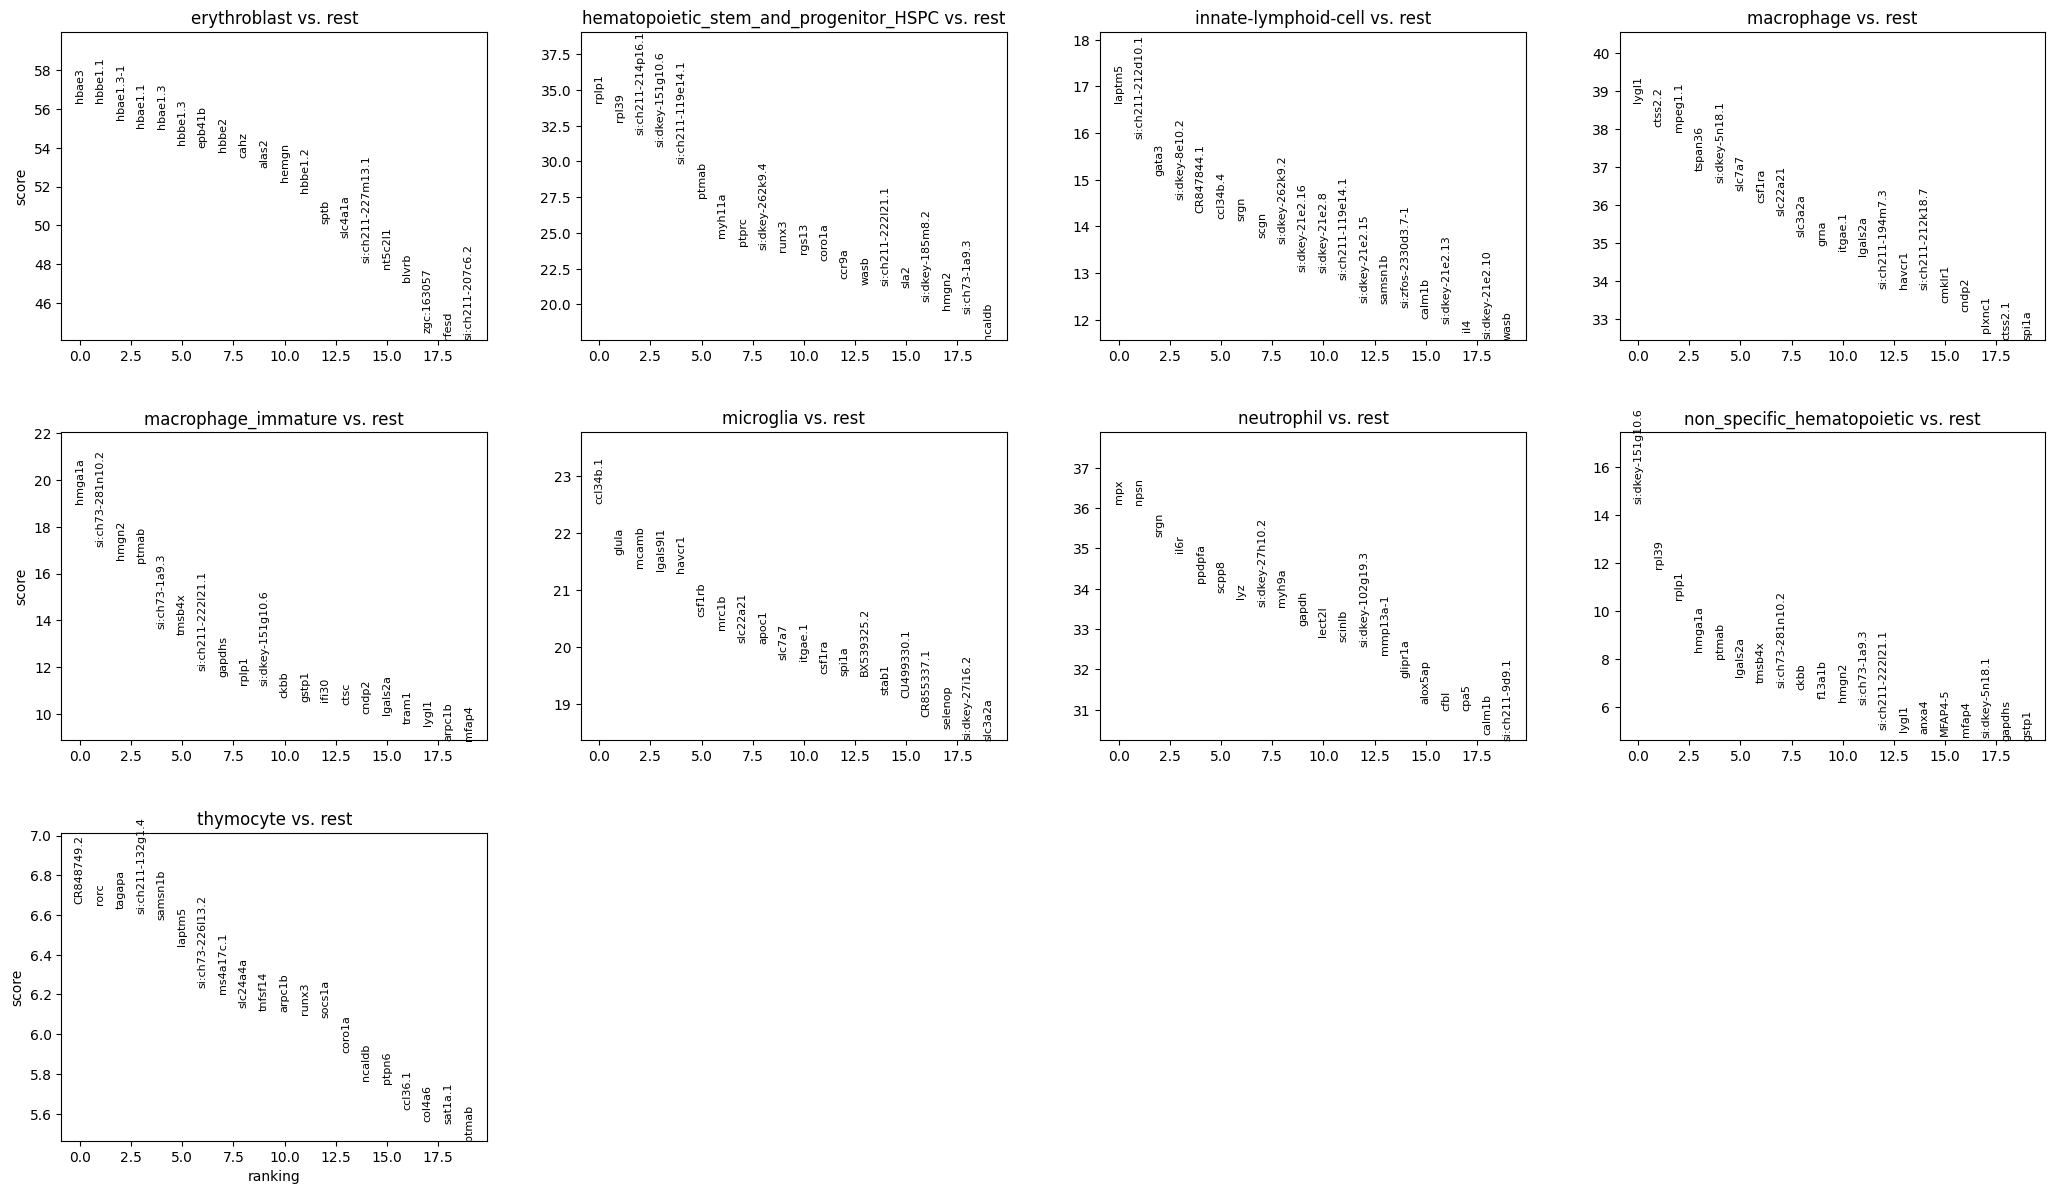

In [8]:
marker_data = blood_clean.copy()
marker_data.X = marker_data.layers["counts"].copy()
sc.pp.normalize_total(marker_data, target_sum=1e4)
sc.pp.log1p(marker_data)
marker_data.obs["official_fine_cell_type"] = marker_data.obs[
    "official_fine_cell_type"
].astype("category")

sc.tl.rank_genes_groups(
    marker_data,
    groupby="official_fine_cell_type",
    reference="rest",
    method="wilcoxon",
    use_raw=False,
    pts=True,
)

marker_tables = []
for official_label in marker_data.obs["official_fine_cell_type"].cat.categories:
    table = sc.get.rank_genes_groups_df(marker_data, group=official_label)
    table.insert(0, "official_fine_cell_type", str(official_label))
    marker_tables.append(table)

data_driven_markers = pd.concat(marker_tables, ignore_index=True)
candidate_markers = data_driven_markers.loc[
    data_driven_markers["pvals_adj"].lt(0.05)
    & data_driven_markers["logfoldchanges"].gt(1.0)
].copy()
candidate_markers = candidate_markers.sort_values(
    ["official_fine_cell_type", "logfoldchanges"],
    ascending=[True, False],
)
candidate_markers.to_csv(
    RESULTS_DIR / "data_driven_candidate_markers.csv", index=False
)
top_candidate_markers = candidate_markers.groupby(
    "official_fine_cell_type", observed=True, group_keys=False
).head(20)
display(top_candidate_markers)

sc.pl.rank_genes_groups(
    marker_data, n_genes=20, sharey=False, show=False
)
plt.savefig(
    FIGURE_DIR / "data_driven_candidate_markers.pdf",
    bbox_inches="tight",
)
plt.show()


In [9]:
type_time_fish = (
    blood_clean.obs.groupby(
        ["official_fine_cell_type", "hpf", "fish_id"], observed=True
    )
    .size().rename("n_cells").reset_index()
)
display(type_time_fish)
type_time_fish.to_csv(RESULTS_DIR / "official_type_time_fish_counts.csv", index=False)

eligible_labels = official_counts[
    official_counts >= MIN_CELLS_PER_FINE_TYPE
].index.astype(str).tolist()

if MODEL_FINE_LABELS is None:
    modeled_labels = eligible_labels
else:
    unknown = sorted(set(MODEL_FINE_LABELS) - set(official_counts.index.astype(str)))
    assert not unknown, f"Requested labels are not official annotations: {unknown}"
    too_small = sorted(set(MODEL_FINE_LABELS) - set(eligible_labels))
    assert not too_small, f"Requested labels have too few cells: {too_small}"
    modeled_labels = list(MODEL_FINE_LABELS)

assert len(modeled_labels) >= 2, "Fewer than two official fine types pass the count gate."
print("Official labels retained for modeling:", modeled_labels)
print("GATE 2: candidate markers were learned from data and never alter labels.")


,official_fine_cell_type,hpf,fish_id,n_cells
0,erythroblast,12.0,TDR35,1
1,erythroblast,12.0,TDR37,5
2,erythroblast,14.0,TDR18,17
3,erythroblast,14.0,TDR19,5
4,erythroblast,14.0,TDR21,3
...,...,...,...,...
201,thymocyte,120.0,TDR51,1
202,thymocyte,240.0,TDR71,4
203,thymocyte,240.0,TDR72,3
204,thymocyte,240.0,TDR73,2


Official labels retained for modeling: ['erythroblast', 'macrophage', 'hematopoietic_stem_and_progenitor_HSPC', 'neutrophil', 'non_specific_hematopoietic', 'macrophage_immature', 'microglia', 'innate-lymphoid-cell']
GATE 2: candidate markers were learned from data and never alter labels.


## 7. Restrict to official labels and run Dynamo preprocessing once

The working object begins from the clean raw-count subset. `recipe_monocle` performs
Dynamo's required normalization and feature selection once. We then compute the PCA
and 30-neighbor graph used by moments, dynamics, and GraphVelo. `blood_clean` remains
unchanged as the raw-count checkpoint. This preprocessing recipe does not mean that
Monocle pseudotime is used.


In [10]:
import dynamo as dyn

model_mask = blood_clean.obs["official_fine_cell_type"].isin(modeled_labels)
adata = blood_clean[model_mask].copy()
adata.obs["model_cell_type"] = pd.Categorical(
    adata.obs["official_fine_cell_type"]
)

# Explicitly start Dynamo from total raw counts.
adata.X = adata.layers["counts"].copy()
processed = dyn.pp.recipe_monocle(
    adata, n_top_genes=min(N_HVG, adata.n_vars)
)
if processed is not None:
    adata = processed

assert "use_for_pca" in adata.var.columns
assert adata.var["use_for_pca"].sum() > 0

# Recompute a deterministic PCA and the requested 30-neighbor graph on the
# Dynamo-preprocessed expression matrix.
sc.tl.pca(
    adata,
    n_comps=min(N_PCS, adata.n_vars - 1, adata.n_obs - 1),
    mask_var="use_for_pca",
    svd_solver="arpack",
    random_state=SEED,
)
sc.pp.neighbors(
    adata,
    n_neighbors=N_NEIGHBORS,
    n_pcs=adata.obsm["X_pca"].shape[1],
    use_rep="X_pca",
    random_state=SEED,
)
print(adata)
print("PCA:", adata.obsm["X_pca"].shape)


|-----? dynamo.preprocessing.deprecated is deprecated.
|-----> recipe_monocle_keep_filtered_cells_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_filtered_cells_key=True
|-----> recipe_monocle_keep_filtered_genes_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_filtered_genes_key=True
|-----> recipe_monocle_keep_raw_layers_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_raw_layers_key=True
|-----> apply Monocole recipe to adata...
|-----> ensure all cell and variable names unique.
|-----> ensure all data in different layers in csr sparse matrix format.
|-----> ensure all labeling data properly collapased
|-----? dynamo detects your data is size factor normalized and/or log transformed. If this is not right, plese set `normalized = False.
|-----> filtering cells...
|-----> 4725 cells passed basic filters.
|-----> filtering gene...
|-----> 951 genes passed basic filters.
|-----> calculating size factor.

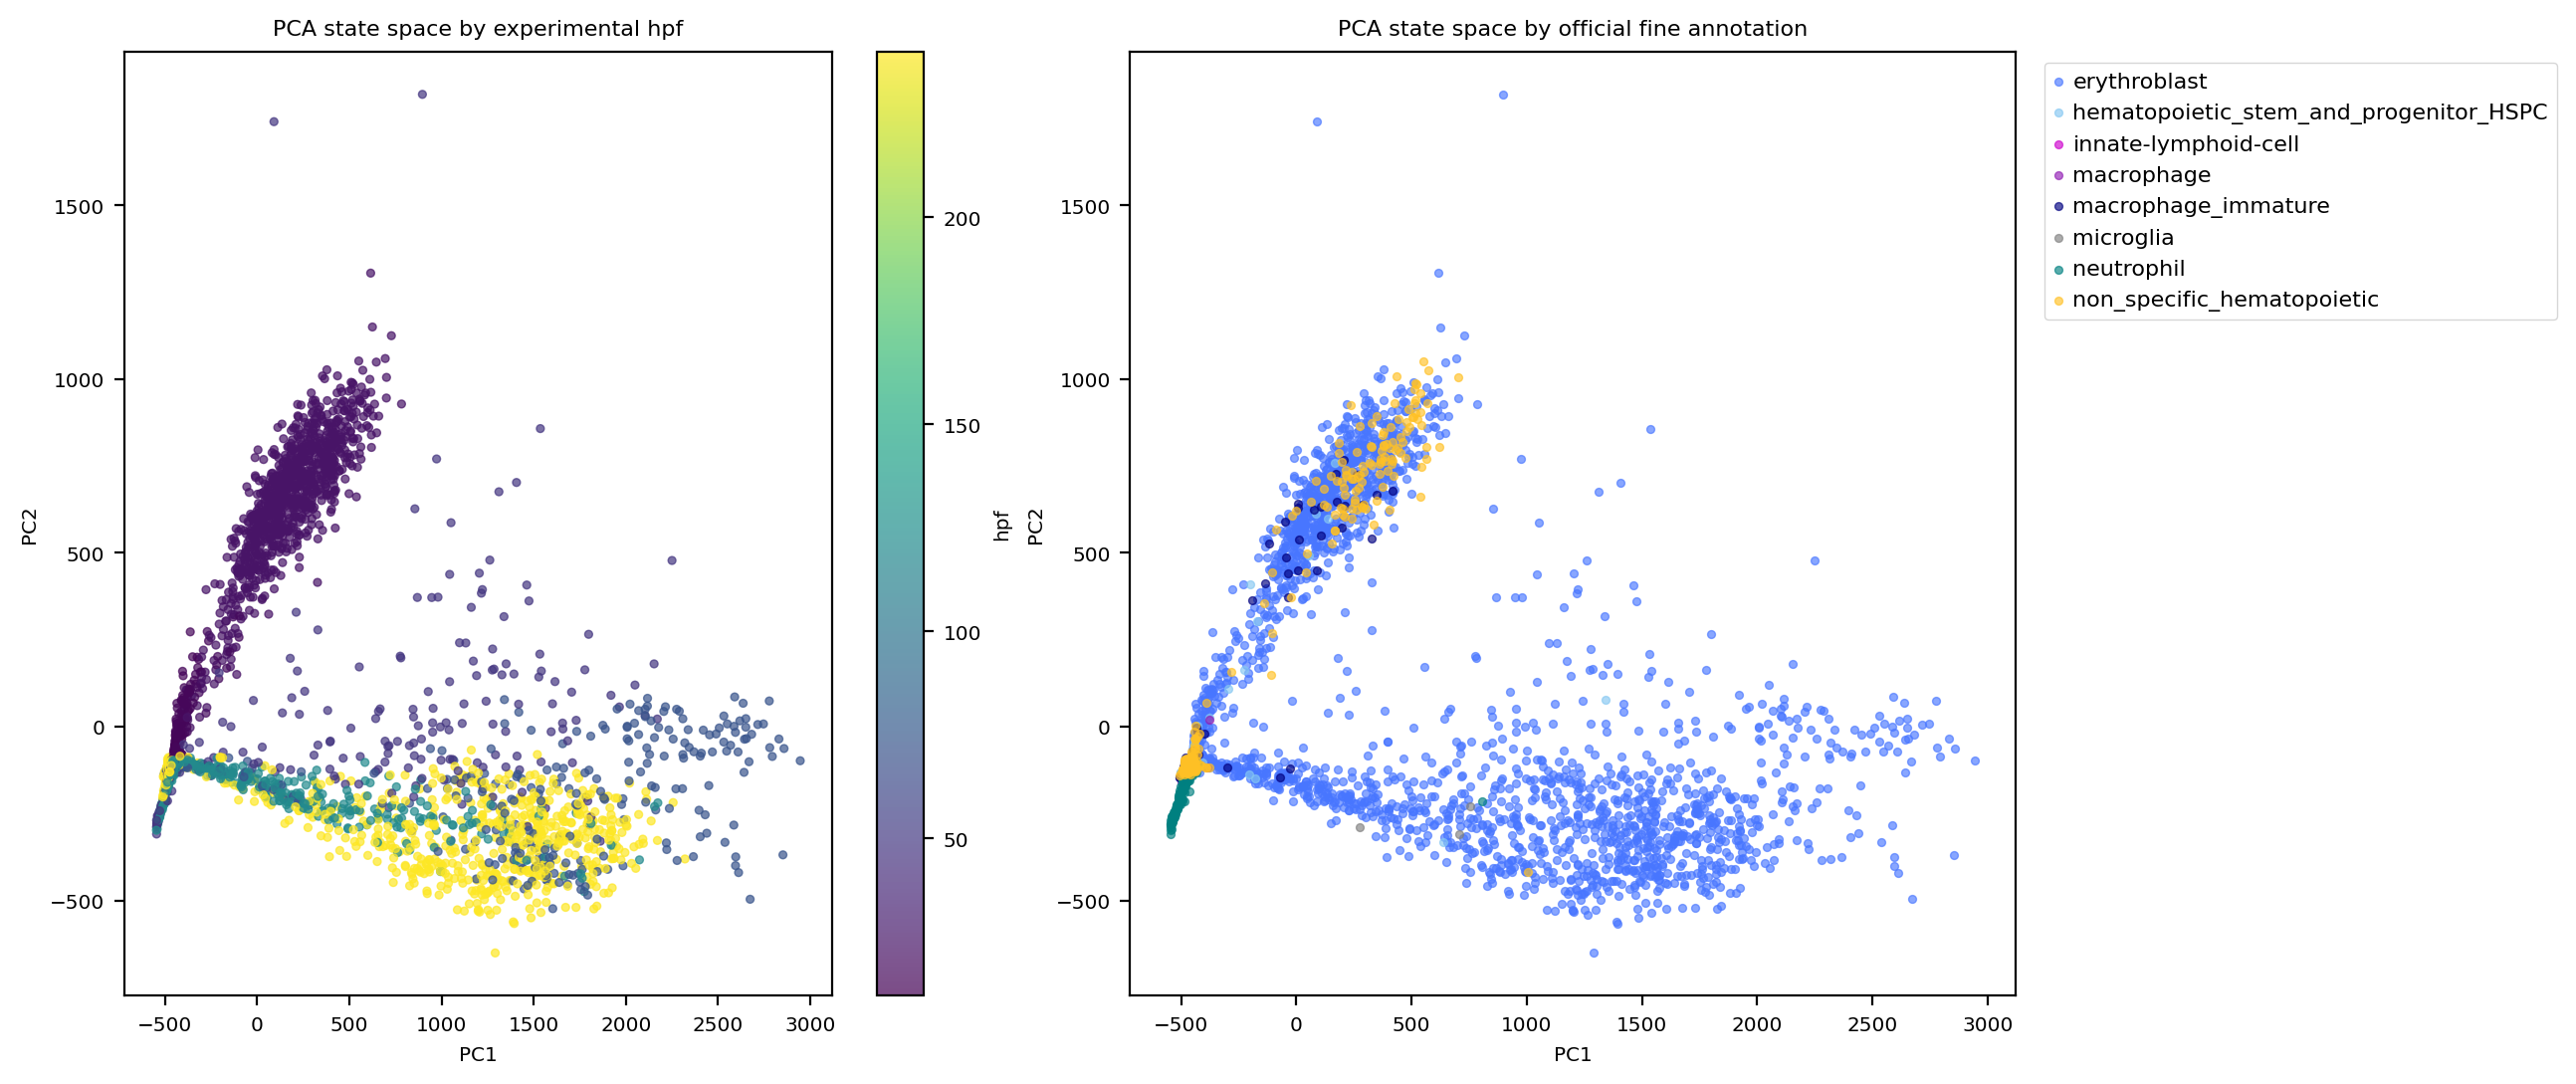

In [11]:
pcs = adata.obsm["X_pca"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

p = axes[0].scatter(
    pcs[:, 0], pcs[:, 1], c=adata.obs["hpf"], cmap="viridis",
    s=8, alpha=0.7, rasterized=True,
)
axes[0].set(title="PCA state space by experimental hpf", xlabel="PC1", ylabel="PC2")
fig.colorbar(p, ax=axes[0], label="hpf")

for official_label in adata.obs["model_cell_type"].cat.categories:
    mask = adata.obs["model_cell_type"].astype(str).eq(str(official_label)).to_numpy()
    axes[1].scatter(
        pcs[mask, 0], pcs[mask, 1], s=8, alpha=0.65,
        label=str(official_label), rasterized=True,
    )
axes[1].set(
    title="PCA state space by official fine annotation", xlabel="PC1", ylabel="PC2"
)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "official_fine_type_pca_state_space.pdf")
plt.show()


## 8. Audit graph continuity across real time

This diagnostic prevents overclaiming a continuous developmental trajectory
when the neighbor graph contains mostly within-stage edges.

In [12]:
C = (adata.obsp["connectivities"] > 0).astype(float).tocsr()
C_coo = C.tocoo()
hpf = adata.obs["hpf"].to_numpy(float)
edge_audit = pd.DataFrame({
    "source_hpf": hpf[C_coo.row],
    "target_hpf": hpf[C_coo.col],
})
edge_table = pd.crosstab(
    edge_audit["source_hpf"],
    edge_audit["target_hpf"],
    normalize="index",
)
display(edge_table.round(3))

same_hpf_fraction = np.mean(
    edge_audit["source_hpf"].to_numpy() == edge_audit["target_hpf"].to_numpy()
)
print(f"Same-hpf kNN edges: {same_hpf_fraction:.1%}")
if same_hpf_fraction > 0.90:
    warnings.warn(
        "More than 90% of kNN edges remain within the same hpf. Interpret "
        "velocity as local state dynamics; do not claim a single continuous "
        "trajectory spanning all sampled stages."
    )

target_hpf,12.0,14.0,16.0,19.0,24.0,48.0,72.0,120.0,240.0
source_hpf,,,,,,,,,
12.0,0.457,0.493,0.016,0.000,0.000,0.016,0.000,0.017,0.002
14.0,0.103,0.575,0.230,0.015,0.008,0.018,0.000,0.039,0.012
16.0,0.001,0.092,0.698,0.102,0.066,0.006,0.001,0.029,0.005
19.0,0.000,0.014,0.247,0.280,0.255,0.051,0.021,0.074,0.056
24.0,0.000,0.001,0.011,0.018,0.910,0.032,0.003,0.014,0.011
48.0,0.001,0.003,0.002,0.009,0.081,0.648,0.044,0.153,0.059
72.0,0.000,0.000,0.000,0.003,0.008,0.040,0.542,0.162,0.245
120.0,0.000,0.002,0.004,0.004,0.010,0.045,0.053,0.747,0.135
240.0,0.000,0.001,0.001,0.003,0.009,0.019,0.088,0.149,0.730


Same-hpf kNN edges: 73.8%


## 9. Dynamo moments and stochastic velocity

`recipe_monocle` has already created Dynamo-compatible normalized layers and
preprocessing flags. This section uses the current 30-neighbor PCA graph to compute
moments, followed by the stochastic steady-state dynamics model. No flags are manually
set to pretend that preprocessing occurred.

In [13]:
assert {"X_spliced", "X_unspliced"}.issubset(adata.layers.keys()), (
    "recipe_monocle did not create normalized X_spliced/X_unspliced layers."
)
A = (adata.obsp["connectivities"] > 0).astype(float).tocsr()
row_sums = np.asarray(A.sum(axis=1)).ravel()
assert np.all(row_sums > 0), "Neighbor graph contains isolated cells."
moments_conn = sp.diags(1.0 / row_sums) @ A

dynamics_genes = adata.var_names[adata.var["pass_basic_filter"].astype(bool)].tolist()
assert len(dynamics_genes) > 0
dyn.tl.moments(
    adata,
    genes=dynamics_genes,
    conn=moments_conn,
    normalize=False,
    use_gaussian_kernel=False,
    layers=["X_spliced", "X_unspliced"],
    n_neighbors=N_NEIGHBORS,
)
assert "M_s" in adata.layers and "M_u" in adata.layers

|-----> calculating first/second moments...
|-----> [moments calculation] completed [0.7169s]

╭─ SUMMARY: moments ─────────────────────────────────────────────────╮
│  Duration: 0.7211s                                                 │
│  Shape:    5,426 x 2,986 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSP   │ ✚ moments_con (sparse matrix, 5426x5426)               │
│                                                                    │
│  ● LAYERS │ ✚ M_s (sparse matrix, 5426x2986)                       │
│           │ ✚ M_ss (sparse matrix, 5426x2986)                      │
│           │ ✚ M_u (sparse matrix, 5426x2986)                       │
│           │ ✚ M_us (sparse matrix, 5426x2986)                      │
│           │ ✚ M_uu (sparse matrix, 5426x2986)      

In [14]:
dyn.tl.dynamics(
    adata,
    filter_gene_mode="final",
    use_smoothed=True,
    assumption_mRNA="ss",
    model="stochastic",
    est_method="gmm",
    log_unnormalized=False,
    re_smooth=False,
    del_2nd_moments=False,
    cores=1
)
assert "velocity_S" in adata.layers
print("Dynamo dynamics complete.")

estimating gamma: 100%|██████████| 951/951 [00:23<00:00, 40.76it/s]



╭─ SUMMARY: dynamics ────────────────────────────────────────────────╮
│  Duration: 24.9316s                                                │
│  Shape:    5,426 x 2,986 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ use_for_dynamics (bool)                              │
│                                                                    │
│  ● UNS    │ ✚ dynamics                                             │
│           │ ✚ vel_params_names                                     │
│                                                                    │
│  ● LAYERS │ ✚ velocity_S (sparse matrix, 5426x2986)                │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
Dynam

## 10. Velocity-gene quality control

The thresholds match the successful pilot:
`gamma > 0`, `gamma_r2 >= 0.01`, finite velocity in at least 95% of cells,
and spliced/unspliced detection in at least 25 cells. The number of passing
genes is data-dependent and is not hard-coded to the pilot's 272 genes.

In [15]:
vel_names = list(adata.uns["vel_params_names"])
vel_params = pd.DataFrame(
    adata.varm["vel_params"],
    index=adata.var_names,
    columns=vel_names,
)

V = adata.layers["velocity_S"]
V_dense = V.toarray() if sp.issparse(V) else np.asarray(V)

def detection_count(matrix):
    return np.asarray((matrix > 0).sum(axis=0)).ravel()

qc = pd.DataFrame(index=adata.var_names)
qc["gamma"] = pd.to_numeric(vel_params["gamma"], errors="coerce")
qc["gamma_r2"] = pd.to_numeric(vel_params["gamma_r2"], errors="coerce")
qc["velocity_finite_fraction"] = np.isfinite(V_dense).mean(axis=0)
qc["spliced_detected_cells"] = detection_count(adata.layers["spliced"])
qc["unspliced_detected_cells"] = detection_count(adata.layers["unspliced"])

valid_velocity_gene = (
    qc["gamma"].gt(0)
    & qc["gamma_r2"].ge(0.01)
    & qc["velocity_finite_fraction"].ge(0.95)
    & qc["spliced_detected_cells"].ge(25)
    & qc["unspliced_detected_cells"].ge(25)
)
adata.var["velocity_qc_pass"] = valid_velocity_gene.to_numpy()
transition_genes = adata.var_names[valid_velocity_gene].tolist()
qc.to_csv(RESULTS_DIR / "velocity_gene_qc.csv")

print("Velocity-QC genes:", len(transition_genes))
assert len(transition_genes) >= 50, (
    "Too few velocity-QC genes. Inspect dynamics and subtype composition "
    "before GraphVelo."
)

Velocity-QC genes: 522


In [16]:
# qc -> 522 

## 11. GraphVelo in expression and PCA state spaces

If the installed GraphVelo source still uses SciPy sparse `.A`, replace those
package-internal occurrences with `.toarray()` once. Do not monkey-patch the
scientific data object.

In [17]:
# Compatibility bridge:
# convert the existing Scanpy neighbor graph into the neighbor-index
# format required by this installed GraphVelo version.

distances = adata.obsp["distances"].tocsr()
n_cells = adata.n_obs
n_neighbors = N_NEIGHBORS

neighbor_indices = np.empty(
    (n_cells, n_neighbors),
    dtype=np.int64,
)

for cell_index in range(n_cells):
    start = distances.indptr[cell_index]
    end = distances.indptr[cell_index + 1]

    row_neighbors = distances.indices[start:end]
    row_distances = distances.data[start:end]

    # Arrange existing neighbors by increasing PCA distance.
    order = np.argsort(row_distances)
    row_neighbors = row_neighbors[order]

    # Dynamo/GraphVelo-style index arrays normally include the cell itself.
    row_neighbors = row_neighbors[
        row_neighbors != cell_index
    ]

    selected = np.concatenate(
        [
            np.array([cell_index], dtype=np.int64),
            row_neighbors[: n_neighbors - 1],
        ]
    )

    # Padding is only needed in the unlikely case that a cell has fewer
    # graph neighbors than requested.
    if len(selected) < n_neighbors:
        selected = np.pad(
            selected,
            (0, n_neighbors - len(selected)),
            mode="edge",
        )

    neighbor_indices[cell_index] = selected

# Preserve the existing Scanpy graph and add only the format GraphVelo needs.
if "neighbors" not in adata.uns:
    adata.uns["neighbors"] = {}

adata.uns["neighbors"]["indices"] = neighbor_indices

print(
    "GraphVelo neighbor indices:",
    adata.uns["neighbors"]["indices"].shape,
)

assert adata.uns["neighbors"]["indices"].shape == (
    adata.n_obs,
    N_NEIGHBORS,
)

assert np.all(
    adata.uns["neighbors"]["indices"] >= 0
)

assert np.all(
    adata.uns["neighbors"]["indices"] < adata.n_obs
)

GraphVelo neighbor indices: (5426, 30)


In [18]:
from graphvelo.graph_velocity import GraphVelo

gene_mask = adata.var_names.isin(transition_genes)
X_train = adata.layers["M_s"][:, gene_mask]
V_train = adata.layers["velocity_S"][:, gene_mask]
assert np.isfinite(
    X_train.data if sp.issparse(X_train) else np.asarray(X_train)
).all()
assert np.isfinite(
    V_train.data if sp.issparse(V_train) else np.asarray(V_train)
).all()

gv = GraphVelo(
    adata,
    gene_subset=transition_genes,
    xkey="M_s",
    vkey="velocity_S",
)
gv.train()

adata.layers["velocity_gv"] = gv.project_velocity(adata.layers["M_s"])
adata.obsm["gv_pca"] = gv.project_velocity(adata.obsm["X_pca"])
gv.write_to_adata(adata, key="graphvelo")

assert adata.obsm["gv_pca"].shape == adata.obsm["X_pca"].shape
assert np.isfinite(adata.obsm["gv_pca"]).all()
print("GraphVelo training and PCA projection complete.")

Learning Phi in tangent space projection.: 100%|██████████| 5426/5426 [01:01<00:00, 88.35it/s] 
projecting velocity vector to low dimensional embedding: 100%|██████████| 5426/5426 [00:01<00:00, 2892.09it/s]
projecting velocity vector to low dimensional embedding: 100%|██████████| 5426/5426 [00:00<00:00, 11394.48it/s]

GraphVelo training and PCA projection complete.


In [19]:
V_input = np.asarray(gv.V)
V_fit = np.asarray(gv.project_velocity(gv.X))
input_norm = np.linalg.norm(V_input, axis=1)
fit_norm = np.linalg.norm(V_fit, axis=1)
denom = input_norm * fit_norm
fit_cosine = np.divide(
    np.sum(V_input * V_fit, axis=1),
    denom,
    out=np.full(len(denom), np.nan),
    where=denom > 0,
)
print(pd.Series(fit_cosine).describe())
if np.nanmedian(fit_cosine) <= 0:
    raise RuntimeError(
        "Median GraphVelo fit cosine is non-positive. Stop before interpreting "
        "directions or weights."
    )

projecting velocity vector to low dimensional embedding: 100%|██████████| 5426/5426 [00:00<00:00, 11895.61it/s]

count    5426.000000
mean        0.508466
std         0.152492
min         0.062338
25%         0.397115
50%         0.506277
75%         0.613106
max         0.918590
dtype: float64


## 12. Cell-level transition matrix and real-time constraint

Dynamo provides the neighbor transition matrix; GraphVelo refines state-space
velocities. We construct the cell transition matrix from GraphVelo PCA
velocities using neighbor displacement cosine similarity, retain positive
support, and remove edges that move backward by more than the allowed
experimental-time tolerance.

This is a real-time constraint, not pseudotime inference.

In [20]:
from sklearn.preprocessing import normalize

X_pca = np.asarray(adata.obsm["X_pca"])
V_pca = np.asarray(adata.obsm["gv_pca"])
distances = adata.obsp["distances"].tocsr()

rows, cols = distances.nonzero()
displacement = X_pca[cols] - X_pca[rows]
disp_norm = np.linalg.norm(displacement, axis=1)
vel_norm = np.linalg.norm(V_pca[rows], axis=1)
denom = disp_norm * vel_norm
cosine = np.divide(
    np.sum(displacement * V_pca[rows], axis=1),
    denom,
    out=np.zeros_like(denom),
    where=denom > 0,
)

# Positive cosine support; exp sharpens direction without inventing new edges.
edge_weight = np.where(cosine > 0, np.exp(5.0 * cosine), 0.0)
T_raw = sp.csr_matrix(
    (edge_weight, (rows, cols)),
    shape=(adata.n_obs, adata.n_obs),
)
T_raw.eliminate_zeros()
T_raw = normalize(T_raw, norm="l1", axis=1)

hpf = adata.obs["hpf"].to_numpy(float)
T_coo = T_raw.tocoo()
forward_time = hpf[T_coo.col] >= (hpf[T_coo.row] - TIME_TOLERANCE_HPF)
T_time = sp.csr_matrix(
    (
        T_coo.data[forward_time],
        (T_coo.row[forward_time], T_coo.col[forward_time]),
    ),
    shape=T_raw.shape,
)
T_time.eliminate_zeros()
T_time = normalize(T_time, norm="l1", axis=1)
adata.obsp["graphvelo_time_constrained_transition"] = T_time

valid_rows = np.asarray(T_time.sum(axis=1)).ravel() > 0
print("Cells with outgoing constrained transition:", valid_rows.sum(), "/", adata.n_obs)
assert valid_rows.mean() > 0.80, "Too many cells lost all outgoing transitions."

Cells with outgoing constrained transition: 5375 / 5426


## 13. Aggregate to directed official-cell-type weights

For source subtype \(A\) and target subtype \(B\):

$$ W_{A \rightarrow B} = \frac{\sum_{i\in A}\sum_{j\in B}T_{ij}} {\sum_{i\in A}\sum_jT_{ij}} $$

The table also reports the unconstrained forward-time fraction and weighted
mean change in hpf. Self-transitions are retained in the CSV but may be hidden
from the lineage figure.

In [21]:
cell_types = adata.obs["official_fine_cell_type"].astype(str).to_numpy()
unique_cell_types = sorted(pd.unique(cell_types))

T_raw_coo = T_raw.tocoo()
raw_edges = pd.DataFrame({
    "source": cell_types[T_raw_coo.row],
    "target": cell_types[T_raw_coo.col],
    "weight": T_raw_coo.data,
    "delta_hpf": hpf[T_raw_coo.col] - hpf[T_raw_coo.row],
})

T_time_coo = T_time.tocoo()
time_edges = pd.DataFrame({
    "source": cell_types[T_time_coo.row],
    "target": cell_types[T_time_coo.col],
    "weight": T_time_coo.data,
    "delta_hpf": hpf[T_time_coo.col] - hpf[T_time_coo.row],
})

raw_stats = raw_edges.groupby(["source", "target"], observed=True).apply(
    lambda d: pd.Series({
        "forward_time_fraction_raw": np.average(
            d["delta_hpf"] >= -TIME_TOLERANCE_HPF, weights=d["weight"]
        )
    }),
)
time_group = time_edges.groupby(["source", "target"], observed=True)
weights = time_group["weight"].sum().rename("edge_mass")
mean_delta = time_group.apply(
    lambda d: np.average(d["delta_hpf"], weights=d["weight"]),
).rename("mean_delta_hpf")

transition = pd.concat([weights, mean_delta, raw_stats], axis=1).reset_index()
source_mass = transition.groupby("source")["edge_mass"].transform("sum")
transition["weight"] = transition["edge_mass"] / source_mass
transition = transition.sort_values(["source", "weight"], ascending=[True, False])
transition.to_csv(RESULTS_DIR / "official_type_transition_weights.csv", index=False)
display(transition)


/tmp/ipykernel_791423/2103985998.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  raw_stats = raw_edges.groupby(["source", "target"], observed=True).apply(
/tmp/ipykernel_791423/2103985998.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_delta = time_group.apply(


,source,target,edge_mass,mean_delta_hpf,forward_time_fraction_raw,weight
0,erythroblast,erythroblast,2036.879998,6.463138,0.917790,0.869718
7,erythroblast,non_specific_hematopoietic,110.447720,5.876632,0.974649,0.047160
1,erythroblast,hematopoietic_stem_and_progenitor_HSPC,76.075992,19.700060,0.926491,0.032483
4,erythroblast,macrophage_immature,63.477838,7.993082,0.851426,0.027104
3,erythroblast,macrophage,37.599928,13.600177,0.798386,0.016055
...,...,...,...,...,...,...
55,non_specific_hematopoietic,hematopoietic_stem_and_progenitor_HSPC,58.892163,40.774178,0.962683,0.128026
58,non_specific_hematopoietic,macrophage_immature,43.860717,10.806143,0.915650,0.095349
59,non_specific_hematopoietic,microglia,15.376735,21.038003,0.879272,0.033428
56,non_specific_hematopoietic,innate-lymphoid-cell,1.474629,36.176869,0.729807,0.003206


## 14. Fish-level bootstrap confidence intervals

Fish—not individual cells—is the resampling unit. This avoids treating many
cells from one fish as independent biological replicates.

In [22]:
rng = np.random.default_rng(SEED)
fish = adata.obs["fish_id"].astype(str).to_numpy()
unique_fish = np.unique(fish)
N_BOOT = 500

def aggregate_transition_for_cells(cell_indices):
    sub = T_time[cell_indices, :]
    records = []
    for source_name in unique_cell_types:
        local_rows = np.flatnonzero(cell_types[cell_indices] == source_name)
        if len(local_rows) == 0:
            continue
        block = sub[local_rows, :]
        masses = [
            (target_name, float(block[:, cell_types == target_name].sum()))
            for target_name in unique_cell_types
        ]
        total = sum(mass for _, mass in masses)
        if total > 0:
            records.extend(
                (source_name, target_name, mass / total)
                for target_name, mass in masses
            )
    return records

bootstrap_records = []
for iteration in range(N_BOOT):
    sampled_fish = rng.choice(unique_fish, size=len(unique_fish), replace=True)
    sampled_cells = np.concatenate([
        np.flatnonzero(fish == fish_id) for fish_id in sampled_fish
    ])
    for source_name, target_name, value in aggregate_transition_for_cells(sampled_cells):
        bootstrap_records.append((iteration, source_name, target_name, value))

boot = pd.DataFrame(
    bootstrap_records, columns=["iteration", "source", "target", "weight"]
)
ci = (
    boot.groupby(["source", "target"])["weight"]
    .quantile([0.025, 0.975]).unstack()
    .rename(columns={0.025: "weight_ci_low", 0.975: "weight_ci_high"})
    .reset_index()
)
transition_ci = transition.merge(ci, on=["source", "target"], how="left")
transition_ci.to_csv(
    RESULTS_DIR / "official_type_transition_weights_bootstrap.csv", index=False
)
display(transition_ci)


,source,target,edge_mass,mean_delta_hpf,forward_time_fraction_raw,weight,weight_ci_low,weight_ci_high
0,erythroblast,erythroblast,2036.879998,6.463138,0.917790,0.869718,0.826691,0.902673
1,erythroblast,non_specific_hematopoietic,110.447720,5.876632,0.974649,0.047160,0.025806,0.070264
2,erythroblast,hematopoietic_stem_and_progenitor_HSPC,76.075992,19.700060,0.926491,0.032483,0.023230,0.046315
3,erythroblast,macrophage_immature,63.477838,7.993082,0.851426,0.027104,0.018206,0.039424
4,erythroblast,macrophage,37.599928,13.600177,0.798386,0.016055,0.008963,0.027139
...,...,...,...,...,...,...,...,...
57,non_specific_hematopoietic,hematopoietic_stem_and_progenitor_HSPC,58.892163,40.774178,0.962683,0.128026,0.081250,0.192093
58,non_specific_hematopoietic,macrophage_immature,43.860717,10.806143,0.915650,0.095349,0.061874,0.146769
59,non_specific_hematopoietic,microglia,15.376735,21.038003,0.879272,0.033428,0.016909,0.057031
60,non_specific_hematopoietic,innate-lymphoid-cell,1.474629,36.176869,0.729807,0.003206,0.000839,0.006104


## 15. Main result: directed weighted official-cell-type network

Nodes are validated official cell types; node size is cell count; node color is
median experimental hpf; edge width is transition weight. Only cross-subtype
edges above the display threshold are plotted.

In [41]:
DISPLAY_WEIGHT = 0.02 # if over .0 the neutrophil would be isolated, .03 has 1 edge, .02 have 2 edges
network_edges = transition_ci[
    (transition_ci["source"] != transition_ci["target"])
    & (transition_ci["weight"] >= DISPLAY_WEIGHT)
].copy()

G = nx.DiGraph()
node_stats = (
    adata.obs.groupby("official_fine_cell_type", observed=True)
    .agg(n_cells=("fish_id", "size"), median_hpf=("hpf", "median"))
)
for label, row in node_stats.iterrows():
    G.add_node(str(label), **row.to_dict())
for row in network_edges.itertuples(index=False):
    G.add_edge(row.source, row.target, weight=row.weight)

fig, ax = plt.subplots(figsize=(11, 8))
pos = nx.spring_layout(G, seed=SEED, k=1.3)
sizes = [300 + 2200 * node_stats.loc[n, "n_cells"] / node_stats["n_cells"].max()
         for n in G.nodes]
colors = [node_stats.loc[n, "median_hpf"] for n in G.nodes]
nodes = nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors,
                               cmap="viridis", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(
    G, pos, width=[1 + 8 * G[u][v]["weight"] for u, v in G.edges],
    arrows=True, arrowsize=18, connectionstyle="arc3,rad=0.08", ax=ax,
)
fig.colorbar(nodes, ax=ax, label="Median experimental hpf")
ax.set_title("Directed transitions among official fine cell types")
ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "official_fine_type_lineage_network.pdf")
plt.show()



TypeError: category dtype does not support aggregation 'median'

## 16. Install/import moscot and define combination parameters

Install moscot in the same environment that already contains the working
GraphVelo object. A separate environment is safer if the existing JAX/NumPy
versions are fragile. Run the commented installation command in a terminal,
not repeatedly inside the notebook.

Parameter roles:

- `MOSCOT_EPSILON`: entropy regularization of optimal transport. Larger values
  make couplings more diffuse.
- `MOSCOT_TAU_A/B`: unbalanced-OT marginal relaxation. Values near 1 are closer
  to balanced transport.
- `OT_TOPK`: number of moscot target candidates retained per source cell.
- `OT_ALPHA`: strength of the moscot probability in the combined model.
- `GV_KAPPA`: strength of GraphVelo directional evidence. `0` reproduces the
  sparsified moscot-only coupling.

No single setting is biologically privileged. The sensitivity section must be
run before reporting a final transition.

In [24]:
import sys

print("当前 kernel 的 Python：")
print(sys.executable)

!{sys.executable} -m pip install "moscot==0.5.1"

当前 kernel 的 Python：
/net/dali/home/mscbio/jis322/.conda/envs/vae_gpu/bin/python


In [25]:
# Terminal installation example (uncomment only when needed):
# %pip install "moscot>=0.4" seaborn

import importlib.metadata as importlib_metadata
import seaborn as sns

try:
    import moscot
    from moscot.problems.time import TemporalProblem
except ImportError as error:
    raise ImportError(
        "moscot is not installed in this kernel. Install it in a compatible "
        "environment, restart the kernel, and rerun the notebook."
    ) from error

print("moscot:", importlib_metadata.version("moscot"))
print("anndata:", importlib_metadata.version("anndata"))
print("scanpy:", importlib_metadata.version("scanpy"))

# Initial values only. Do not treat them as final without sensitivity testing.
MOSCOT_EPSILON = 1e-2
MOSCOT_TAU_A = 0.9
MOSCOT_TAU_B = 0.9
OT_TOPK = 50
OT_ALPHA = 1.0
GV_KAPPA = 2.0

# Numerical protection for logs/divisions; it has no biological meaning.
NUMERIC_EPS = 1e-12

moscot: 0.5.1
anndata: 0.10.9
scanpy: 1.11.5


## 17. Audit the shared state space and experimental time

moscot and GraphVelo must refer to the **same cells in the same PCA
coordinates**. The time key is the actual numeric hpf value—not a categorical
code such as 0,1,2,... . With `policy="sequential"`, moscot will solve
12→14, 14→16, ..., 120→240 hpf.

The official cell label is converted to categorical only for aggregation. It
does not enter the transport cost.

In [26]:
required_obsm = {"X_pca", "gv_pca"}
required_obs = {"hpf", "official_fine_cell_type", "fish_id"}

assert required_obsm.issubset(adata.obsm.keys()), (
    f"Missing obsm keys: {required_obsm - set(adata.obsm.keys())}"
)
assert required_obs.issubset(adata.obs.columns), (
    f"Missing obs keys: {required_obs - set(adata.obs.columns)}"
)

adata.obs["hpf"] = pd.to_numeric(adata.obs["hpf"], errors="raise").astype(float)
adata.obs["official_fine_cell_type"] = pd.Categorical(
    adata.obs["official_fine_cell_type"]
)
adata.obs["fish_id"] = adata.obs["fish_id"].astype(str)

X_pca = np.asarray(adata.obsm["X_pca"], dtype=float)
V_pca = np.asarray(adata.obsm["gv_pca"], dtype=float)
hpf = adata.obs["hpf"].to_numpy(float)
cell_types = adata.obs["official_fine_cell_type"].astype(str).to_numpy()
fish_ids = adata.obs["fish_id"].astype(str).to_numpy()

assert X_pca.shape == V_pca.shape
assert X_pca.shape[0] == adata.n_obs
assert np.isfinite(X_pca).all()
assert np.isfinite(V_pca).all()
assert np.isfinite(hpf).all()

timepoints = np.sort(np.unique(hpf))
time_pairs = list(zip(timepoints[:-1], timepoints[1:]))

time_inventory = (
    adata.obs.groupby("hpf", observed=True)
    .agg(
        n_cells=("fish_id", "size"),
        n_fish=("fish_id", "nunique"),
        n_types=("official_fine_cell_type", "nunique"),
    )
)
display(time_inventory)
print("Sequential time pairs:", time_pairs)

# Large gaps require extra caution because a local RNA-velocity direction is
# being compared with a long cross-time displacement.
pair_gaps = pd.Series(
    {f"{t0:g}->{t1:g}": t1 - t0 for t0, t1 in time_pairs},
    name="delta_hpf",
)
display(pair_gaps.to_frame())

,n_cells,n_fish,n_types
hpf,,,
12.0,19,4,4
14.0,77,4,5
16.0,186,4,6
19.0,79,4,6
24.0,1177,4,7
48.0,466,4,7
72.0,528,4,7
120.0,1456,4,8
240.0,1438,4,8


Sequential time pairs: [(np.float64(12.0), np.float64(14.0)), (np.float64(14.0), np.float64(16.0)), (np.float64(16.0), np.float64(19.0)), (np.float64(19.0), np.float64(24.0)), (np.float64(24.0), np.float64(48.0)), (np.float64(48.0), np.float64(72.0)), (np.float64(72.0), np.float64(120.0)), (np.float64(120.0), np.float64(240.0))]


,delta_hpf
12->14,2.0
14->16,2.0
16->19,3.0
19->24,5.0
24->48,24.0
48->72,24.0
72->120,48.0
120->240,120.0


In [27]:
# did the PCA was fitted jointly

print(adata.obsm["X_pca"].shape)
print(np.isfinite(adata.obsm["X_pca"]).all())
print(adata.obs["hpf"].value_counts().sort_index())

(5426, 50)
True
hpf
12.0       19
14.0       77
16.0      186
19.0       79
24.0     1177
48.0      466
72.0      528
120.0    1456
240.0    1438
Name: count, dtype: int64


In [28]:
# Validate the inputs used to construct temporal couplings
TIME_KEY = "hpf"
STATE_KEY = "X_pca"
N_PCS_MOSCOT = 30
MIN_CELLS_PRIMARY = 50

assert TIME_KEY in adata.obs, f"{TIME_KEY!r} is missing from adata.obs"
assert STATE_KEY in adata.obsm, f"{STATE_KEY!r} is missing from adata.obsm"

hpf = adata.obs[TIME_KEY].astype(float).to_numpy()
X_state = np.asarray(adata.obsm[STATE_KEY])[:, :N_PCS_MOSCOT]

assert len(hpf) == adata.n_obs
assert X_state.shape[0] == adata.n_obs
assert X_state.shape[1] == N_PCS_MOSCOT
assert np.isfinite(hpf).all()
assert np.isfinite(X_state).all()

time_counts = (
    pd.Series(hpf, name="hpf")
    .value_counts()
    .sort_index()
)

display(time_counts.rename("n_cells").to_frame())

under_sampled = time_counts[time_counts < MIN_CELLS_PRIMARY]

if len(under_sampled):
    print("Under-sampled stages:")
    display(under_sampled.rename("n_cells").to_frame())

# Store a dedicated shared state representation for moscot.
# This does not combine hpf with PCA.
adata.obsm["X_moscot"] = X_state.copy()

print("moscot state matrix:", adata.obsm["X_moscot"].shape)
print("Experimental stages:", sorted(np.unique(hpf)))

,n_cells
hpf,
12.0,19
14.0,77
16.0,186
19.0,79
24.0,1177
48.0,466
72.0,528
120.0,1456
240.0,1438


Under-sampled stages:


,n_cells
hpf,
12.0,19


moscot state matrix: (5426, 30)
Experimental stages: [np.float64(12.0), np.float64(14.0), np.float64(16.0), np.float64(19.0), np.float64(24.0), np.float64(48.0), np.float64(72.0), np.float64(120.0), np.float64(240.0)]


## 18. Fit moscot temporal optimal transport

The first baseline uses uniform cell marginals. This avoids importing
human/mouse proliferation marker sets into zebrafish without validation.

`joint_attr="X_pca"` instructs moscot to calculate transport costs in the exact
PCA space used for GraphVelo projection. `policy="sequential"` creates only
consecutive-time problems.

After fitting, inspect convergence for every pair. Do not proceed if any
subproblem failed.

In [29]:
tp = TemporalProblem(adata)

tp = tp.prepare(
    time_key="hpf",
    joint_attr="X_pca",
    policy="sequential",
    cost="sq_euclidean",
)

tp = tp.solve(
    epsilon=MOSCOT_EPSILON,
    tau_a=MOSCOT_TAU_A,
    tau_b=MOSCOT_TAU_B,
)

print("Prepared moscot problems:", list(tp.problems.keys()))
print("Solved moscot problems:", list(tp.solutions.keys()))

expected_pairs = {(float(t0), float(t1)) for t0, t1 in time_pairs}
solved_pairs = {(float(a), float(b)) for a, b in tp.solutions.keys()}
assert expected_pairs.issubset(solved_pairs), (
    f"Missing solved time pairs: {expected_pairs - solved_pairs}"
)

convergence_rows = []
for t0, t1 in time_pairs:
    solution = tp.solutions[(t0, t1)]
    convergence_rows.append({
        "source_hpf": t0,
        "target_hpf": t1,
        "converged": getattr(solution, "converged", np.nan),
        "cost": getattr(solution, "cost", np.nan),
    })

moscot_convergence = pd.DataFrame(convergence_rows)
display(moscot_convergence)

known_convergence = moscot_convergence["converged"].dropna()
if len(known_convergence):
    assert known_convergence.astype(bool).all(), "At least one moscot pair did not converge."

INFO     Solving `8` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(79, 1177)].                                    
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(466, 528)].                                    
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(186, 79)].                                     
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(528, 1456)].                                   
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(77, 186)].                                     
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1456, 1438)].                                  
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1177, 466)].                                   
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(19, 

,source_hpf,target_hpf,converged,cost
0,12.0,14.0,True,0.131045
1,14.0,16.0,True,0.120568
2,16.0,19.0,True,0.102971
3,19.0,24.0,True,0.111933
4,24.0,48.0,True,0.119583
5,48.0,72.0,True,0.068342
6,72.0,120.0,True,0.062445
7,120.0,240.0,True,0.063822


## 19. Utilities: materialize and sparsify each coupling

moscot may return a NumPy/JAX dense matrix, a sparse matrix, or a low-rank
output depending on version and solver. This helper converts a solved pair to a
CSR matrix and retains only the largest `OT_TOPK` targets in each source row.

Top-k sparsification is required because all-pairs couplings can be dense. It
also prevents tiny entropy-induced probabilities from becoming apparent
biological edges. The retained-mass fraction is reported so that top-k is
auditable.

In [30]:
def solution_to_csr(solution):
    # Materialize a moscot solution as a finite non-negative CSR matrix.
    matrix = solution.transport_matrix
    if sp.issparse(matrix):
        out = matrix.tocsr().astype(float)
    else:
        out = sp.csr_matrix(np.asarray(matrix, dtype=float))

    if out.nnz:
        assert np.isfinite(out.data).all(), "Non-finite OT mass detected."
        assert (out.data >= 0).all(), "Negative OT mass detected."
    return out


def keep_topk_per_row(matrix, k):
    # Keep at most k largest positive entries per CSR row.
    matrix = matrix.tocsr()
    rows, cols, vals = [], [], []

    for row in range(matrix.shape[0]):
        start, end = matrix.indptr[row], matrix.indptr[row + 1]
        row_cols = matrix.indices[start:end]
        row_vals = matrix.data[start:end]

        positive = row_vals > 0
        row_cols = row_cols[positive]
        row_vals = row_vals[positive]

        if len(row_vals) > k:
            chosen = np.argpartition(row_vals, -k)[-k:]
            row_cols = row_cols[chosen]
            row_vals = row_vals[chosen]

        rows.extend([row] * len(row_vals))
        cols.extend(row_cols.tolist())
        vals.extend(row_vals.tolist())

    return sp.csr_matrix(
        (vals, (rows, cols)),
        shape=matrix.shape,
        dtype=float,
    )


def row_normalize_csr(matrix):
    # Return a row-stochastic CSR matrix; zero rows remain zero.
    matrix = matrix.tocsr()
    row_sum = np.asarray(matrix.sum(axis=1)).ravel()
    inverse = np.divide(
        1.0,
        row_sum,
        out=np.zeros_like(row_sum, dtype=float),
        where=row_sum > 0,
    )
    return sp.diags(inverse) @ matrix

## 20. Combine moscot coupling with GraphVelo directional evidence

For each retained moscot edge (i\rightarrow j), calculate the cosine between
the GraphVelo velocity at the source and the cross-time PCA displacement.

The GraphVelo term is **soft**, not a hard deletion. This matters because the
observed median GraphVelo fit cosine is moderate rather than perfect. With
`GV_KAPPA=2`, a cosine of +0.5 multiplies the edge by about 2.72, while −0.5
multiplies it by about 0.37.

Three objects are retained for every time pair:

- `P_ot`: sparsified, row-normalized moscot-only coupling;
- `Q_combined`: moscot × GraphVelo coupling;
- `edge_table`: auditable per-edge masses, cosine, and indices.

In [31]:
combined_pairs = {}
pair_diagnostics = []

for t0, t1 in time_pairs:
    source_global = np.flatnonzero(hpf == t0)
    target_global = np.flatnonzero(hpf == t1)

    solution = tp.solutions[(t0, t1)]
    P_full = solution_to_csr(solution)

    assert P_full.shape == (len(source_global), len(target_global)), (
        f"Unexpected coupling shape for {t0}->{t1}: {P_full.shape}"
    )

    full_mass = float(P_full.sum())
    P_topk_raw = keep_topk_per_row(P_full, OT_TOPK)
    retained_mass = float(P_topk_raw.sum())
    P_ot = row_normalize_csr(P_topk_raw)

    P_coo = P_topk_raw.tocoo()
    src_local = P_coo.row
    tgt_local = P_coo.col
    ot_mass_raw = P_coo.data
    src_global = source_global[src_local]
    tgt_global = target_global[tgt_local]

    displacement = X_pca[tgt_global] - X_pca[src_global]
    source_velocity = V_pca[src_global]
    denominator = (
        np.linalg.norm(displacement, axis=1)
        * np.linalg.norm(source_velocity, axis=1)
    )
    cosine = np.divide(
        np.sum(source_velocity * displacement, axis=1),
        denominator,
        out=np.zeros(len(denominator), dtype=float),
        where=denominator > 0,
    )
    cosine = np.clip(cosine, -1.0, 1.0)

    # Product-of-experts combination. Adding NUMERIC_EPS avoids log(0).
    log_mass = (
        OT_ALPHA * np.log(ot_mass_raw + NUMERIC_EPS)
        + GV_KAPPA * cosine
    )

    # Stabilize exponentiation independently within each source row.
    row_log_max = np.full(len(source_global), -np.inf)
    np.maximum.at(row_log_max, src_local, log_mass)
    combined_raw = np.exp(log_mass - row_log_max[src_local])

    Q_raw = sp.csr_matrix(
        (combined_raw, (src_local, tgt_local)),
        shape=P_full.shape,
    )
    Q_combined = row_normalize_csr(Q_raw)

    # Reconstruct normalized per-edge masses in the original COO ordering.
    q_row_sum = np.bincount(
        src_local,
        weights=combined_raw,
        minlength=len(source_global),
    )
    q_edge_mass = combined_raw / q_row_sum[src_local]

    p_row_sum = np.bincount(
        src_local,
        weights=ot_mass_raw,
        minlength=len(source_global),
    )
    p_edge_mass = ot_mass_raw / p_row_sum[src_local]

    edge_table = pd.DataFrame({
        "source_hpf": t0,
        "target_hpf": t1,
        "source_local": src_local,
        "target_local": tgt_local,
        "source_global": src_global,
        "target_global": tgt_global,
        "source_type": cell_types[src_global],
        "target_type": cell_types[tgt_global],
        "source_fish": fish_ids[src_global],
        "target_fish": fish_ids[tgt_global],
        "ot_mass": p_edge_mass,
        "gv_cosine": cosine,
        "combined_mass": q_edge_mass,
    })

    ot_mean_cosine = np.average(cosine, weights=p_edge_mass)
    combined_mean_cosine = np.average(cosine, weights=q_edge_mass)
    ot_negative_mass = p_edge_mass[cosine < 0].sum() / p_edge_mass.sum()
    combined_negative_mass = q_edge_mass[cosine < 0].sum() / q_edge_mass.sum()

    pair_diagnostics.append({
        "source_hpf": t0,
        "target_hpf": t1,
        "delta_hpf": t1 - t0,
        "n_source_cells": len(source_global),
        "n_target_cells": len(target_global),
        "retained_ot_mass_fraction": retained_mass / full_mass if full_mass else np.nan,
        "n_retained_edges": len(edge_table),
        "ot_weighted_mean_cosine": ot_mean_cosine,
        "combined_weighted_mean_cosine": combined_mean_cosine,
        "ot_negative_cosine_mass": ot_negative_mass,
        "combined_negative_cosine_mass": combined_negative_mass,
        "combined_nonzero_rows": int((np.asarray(Q_combined.sum(axis=1)).ravel() > 0).sum()),
    })

    combined_pairs[(t0, t1)] = {
        "source_global": source_global,
        "target_global": target_global,
        "P_ot": P_ot,
        "Q_combined": Q_combined,
        "edge_table": edge_table,
    }

pair_diagnostics = pd.DataFrame(pair_diagnostics)
display(pair_diagnostics)
pair_diagnostics.to_csv(
    RESULTS_DIR / "moscot_graphvelo_pair_diagnostics.csv",
    index=False,
)

assert (
    pair_diagnostics["combined_weighted_mean_cosine"]
    >= pair_diagnostics["ot_weighted_mean_cosine"] - 1e-10
).all(), "GraphVelo weighting unexpectedly reduced directional alignment."

,source_hpf,target_hpf,delta_hpf,n_source_cells,n_target_cells,retained_ot_mass_fraction,n_retained_edges,ot_weighted_mean_cosine,combined_weighted_mean_cosine,ot_negative_cosine_mass,combined_negative_cosine_mass,combined_nonzero_rows
0,12.0,14.0,2.0,19,77,0.999953,780,0.681123,0.712511,0.000434,0.000095,19
1,14.0,16.0,2.0,77,186,0.999519,3843,0.152898,0.234807,0.400375,0.312317,77
2,16.0,19.0,3.0,186,79,1.000000,8709,0.100074,0.215720,0.448130,0.351667,186
3,19.0,24.0,5.0,79,1177,0.593801,3950,0.196852,0.307349,0.302430,0.225301,79
4,24.0,48.0,24.0,1177,466,0.497752,58840,0.010902,0.081322,0.497408,0.420685,1177
5,48.0,72.0,24.0,466,528,0.474335,23300,0.267659,0.359327,0.260696,0.163239,466
6,72.0,120.0,48.0,528,1456,0.272016,24284,-0.015456,0.058866,0.509783,0.440346,528
7,120.0,240.0,120.0,1456,1438,0.452887,71813,-0.081690,0.068080,0.579584,0.432734,1456


## 21. Aggregate cell-level couplings to official cell-type transitions

The official annotation is used only now, after both models have been fit.
Within each source type, weights are normalized to sum to one. Therefore the
reported number is a model-supported transition mass, not a literal fraction
of cells or lineage-tracing probability.

Both moscot-only and combined results are retained to reveal how much GraphVelo
changes the temporal OT conclusion.

,source_hpf,target_hpf,source,target,mass,weight,model
47,14.0,16.0,hematopoietic_stem_and_progenitor_HSPC,hematopoietic_stem_and_progenitor_HSPC,1.532878,0.510959,P_ot
49,14.0,16.0,hematopoietic_stem_and_progenitor_HSPC,macrophage_immature,1.070297,0.356766,P_ot
46,14.0,16.0,hematopoietic_stem_and_progenitor_HSPC,erythroblast,0.232844,0.077615,P_ot
50,14.0,16.0,hematopoietic_stem_and_progenitor_HSPC,neutrophil,0.096430,0.032143,P_ot
51,14.0,16.0,hematopoietic_stem_and_progenitor_HSPC,non_specific_hematopoietic,0.055155,0.018385,P_ot
...,...,...,...,...,...,...,...
611,120.0,240.0,hematopoietic_stem_and_progenitor_HSPC,non_specific_hematopoietic,11.693745,0.061546,Q_combined
607,120.0,240.0,hematopoietic_stem_and_progenitor_HSPC,macrophage,11.224081,0.059074,Q_combined
608,120.0,240.0,hematopoietic_stem_and_progenitor_HSPC,macrophage_immature,9.713641,0.051124,Q_combined
606,120.0,240.0,hematopoietic_stem_and_progenitor_HSPC,innate-lymphoid-cell,4.675853,0.024610,Q_combined


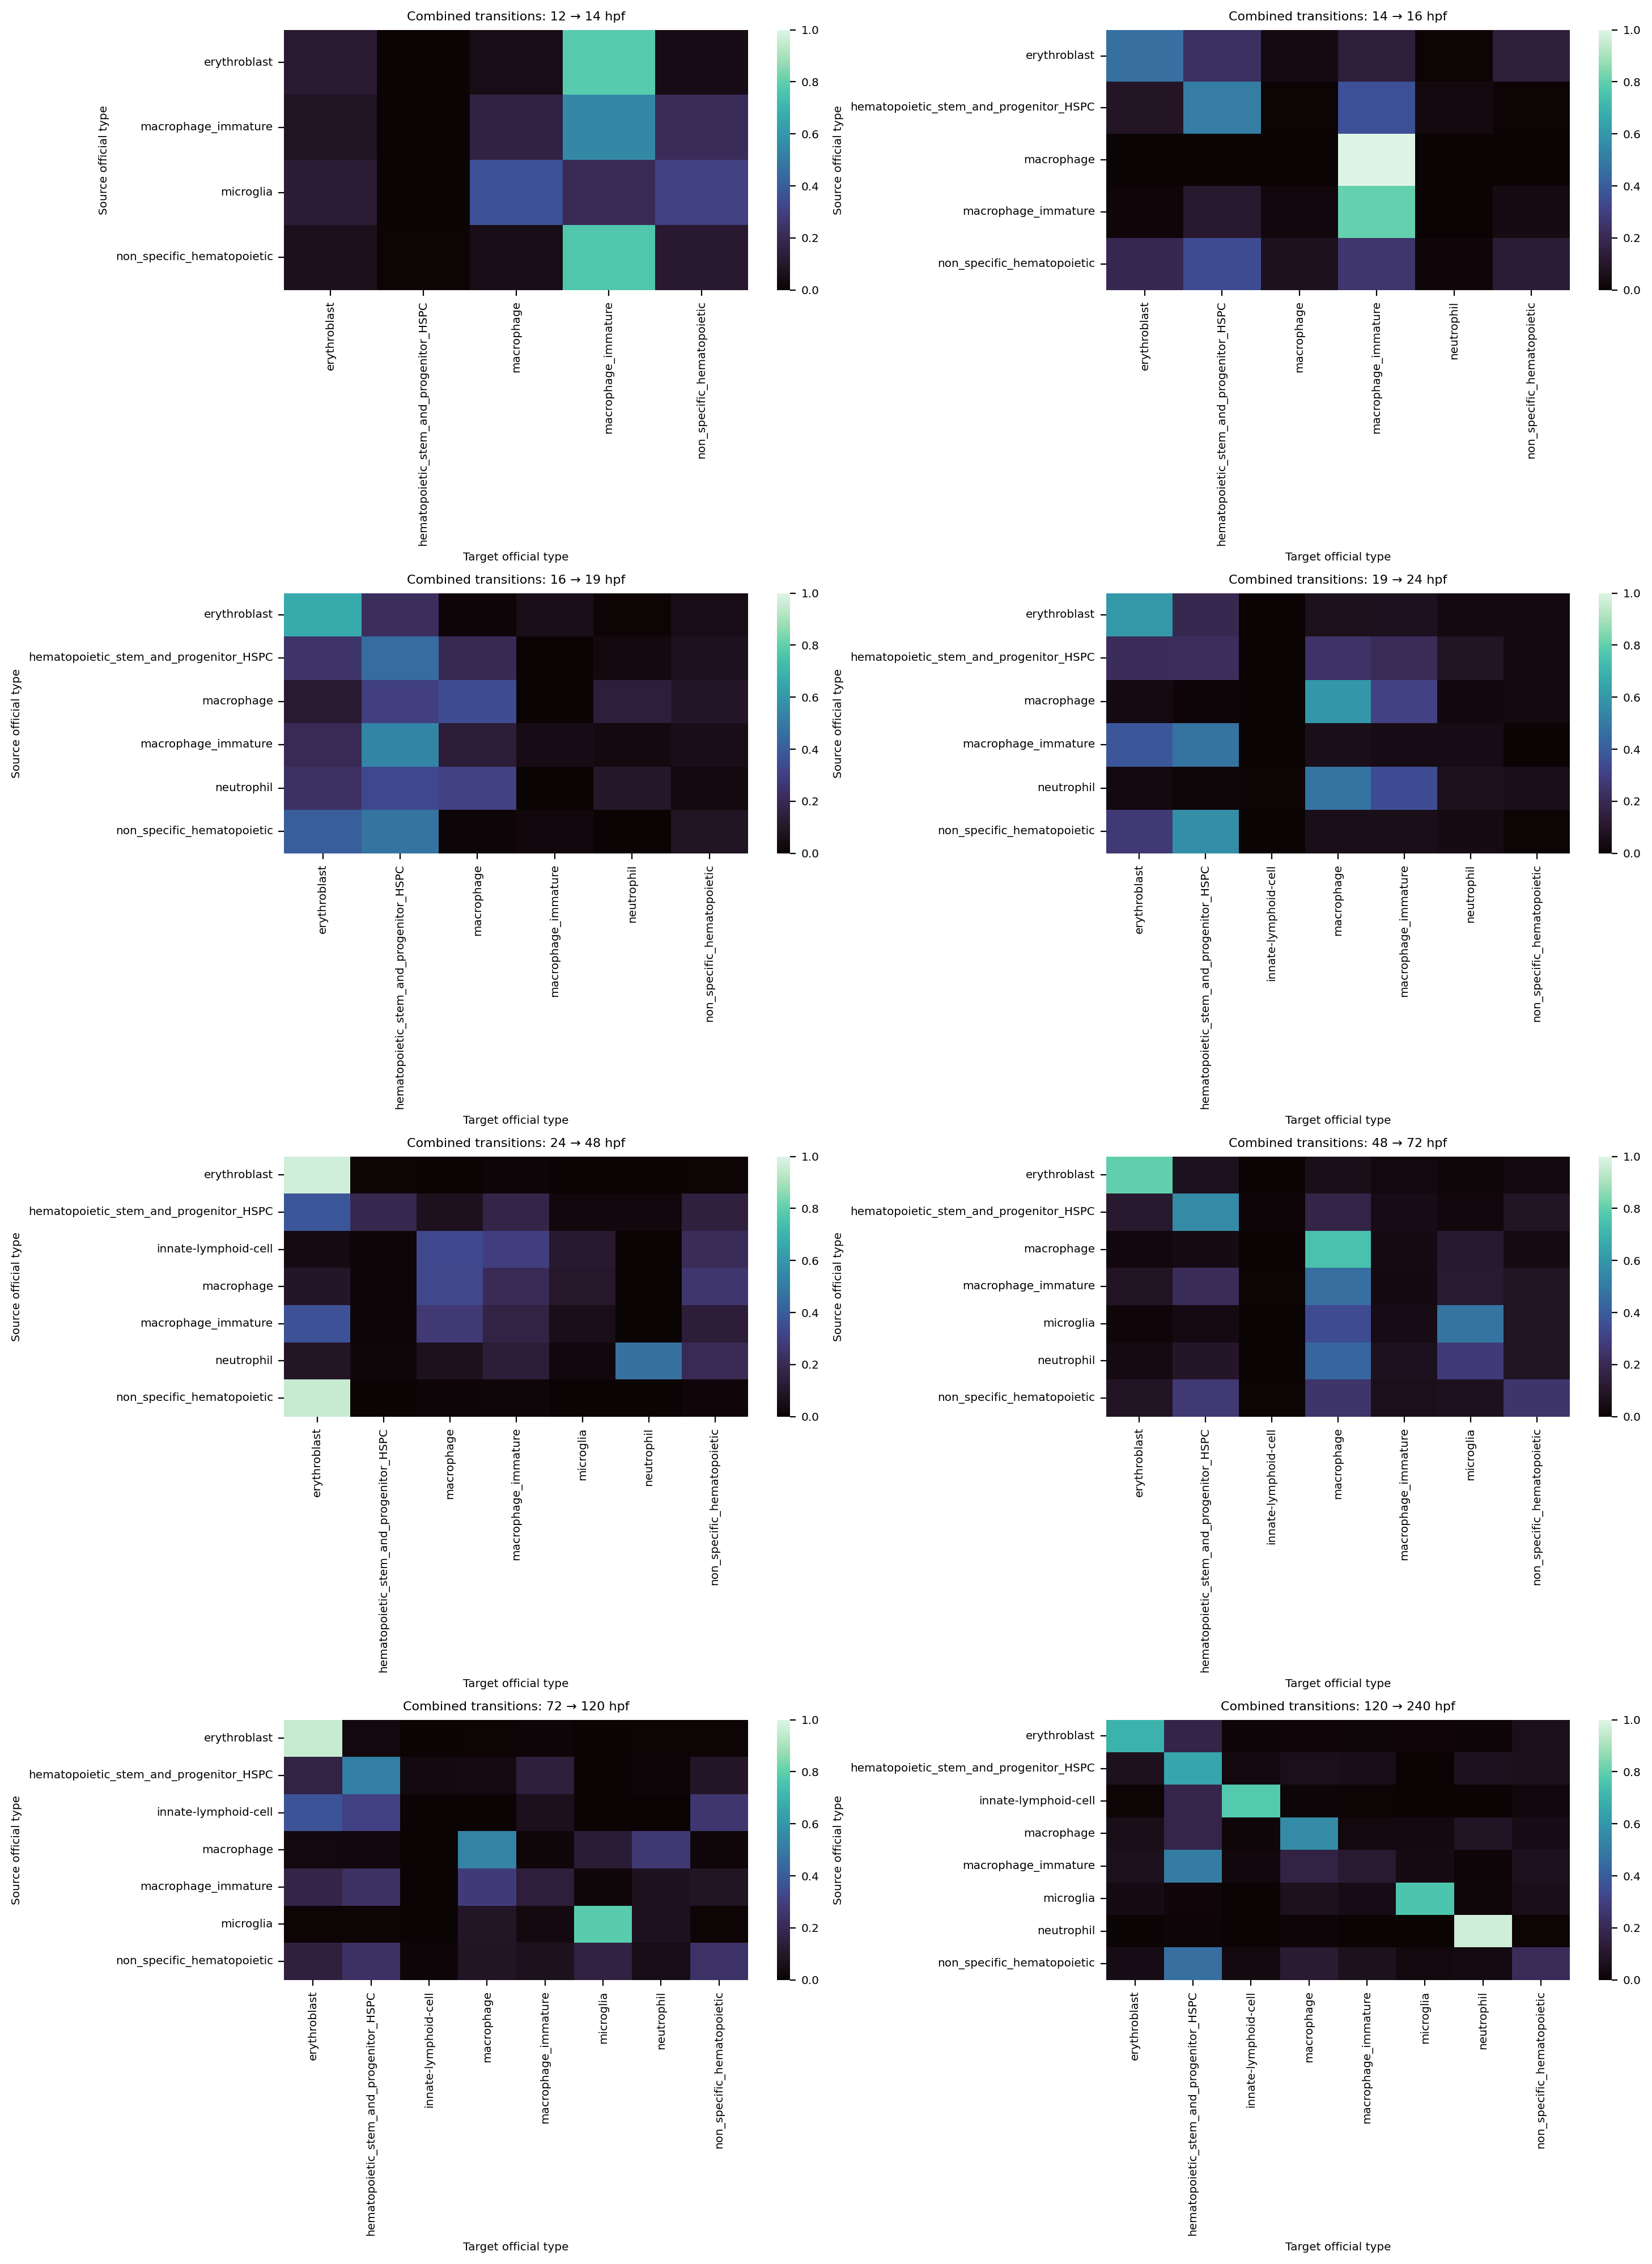

In [32]:
def aggregate_pair_by_type(pair_result, matrix_key, t0, t1):
    # Aggregate a local source-by-target coupling by official annotations.
    matrix = pair_result[matrix_key].tocoo()
    src_global = pair_result["source_global"][matrix.row]
    tgt_global = pair_result["target_global"][matrix.col]

    frame = pd.DataFrame({
        "source_hpf": t0,
        "target_hpf": t1,
        "source": cell_types[src_global],
        "target": cell_types[tgt_global],
        "mass": matrix.data,
    })

    grouped = (
        frame.groupby(
            ["source_hpf", "target_hpf", "source", "target"],
            observed=True,
        )["mass"]
        .sum()
        .reset_index()
    )

    source_total = grouped.groupby(
        ["source_hpf", "target_hpf", "source"],
        observed=True,
    )["mass"].transform("sum")
    grouped["weight"] = grouped["mass"] / source_total
    grouped["model"] = matrix_key
    return grouped


type_transition_frames = []
for (t0, t1), pair_result in combined_pairs.items():
    type_transition_frames.append(
        aggregate_pair_by_type(pair_result, "P_ot", t0, t1)
    )
    type_transition_frames.append(
        aggregate_pair_by_type(pair_result, "Q_combined", t0, t1)
    )

temporal_type_transitions = pd.concat(
    type_transition_frames,
    ignore_index=True,
)
temporal_type_transitions.to_csv(
    RESULTS_DIR / "moscot_graphvelo_temporal_type_transitions.csv",
    index=False,
)

# Show HSPC transitions at every interval in which HSPC exists as a source.
HSPC_LABEL = "hematopoietic_stem_and_progenitor_HSPC"
hspc_temporal = temporal_type_transitions.loc[
    temporal_type_transitions["source"].eq(HSPC_LABEL)
].sort_values(
    ["source_hpf", "model", "weight"],
    ascending=[True, True, False],
)
display(hspc_temporal)

# Heatmaps for the combined model. Empty cell-type combinations appear as 0.
combined_type_only = temporal_type_transitions.loc[
    temporal_type_transitions["model"].eq("Q_combined")
]

n_pairs = len(time_pairs)
ncols = 2
nrows = int(np.ceil(n_pairs / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows), squeeze=False)

for ax, (t0, t1) in zip(axes.ravel(), time_pairs):
    subset = combined_type_only.loc[
        (combined_type_only["source_hpf"] == t0)
        & (combined_type_only["target_hpf"] == t1)
    ]
    table = subset.pivot_table(
        index="source",
        columns="target",
        values="weight",
        fill_value=0.0,
        observed=True,
    )
    sns.heatmap(table, cmap="mako", vmin=0, vmax=1, ax=ax)
    ax.set_title(f"Combined transitions: {t0:g} → {t1:g} hpf")
    ax.set_xlabel("Target official type")
    ax.set_ylabel("Source official type")

for ax in axes.ravel()[n_pairs:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "moscot_graphvelo_type_transition_heatmaps.pdf")
plt.show()

## 22. HSPC push-forward fate distributions through multiple time points

Sequential coupling matrices can be multiplied because the target cells at one
stage are the source cells at the next stage. Starting from a uniform
distribution over HSPCs at the earliest stage containing HSPCs, this section
propagates probability mass forward and summarizes it by official type.

This is a model-based fate distribution. It is not clonal ancestry and should
not be reported as a measured differentiation fraction.

,cell_type,mass,hpf
1,hematopoietic_stem_and_progenitor_HSPC,0.509264,16.0
3,macrophage_immature,0.358365,16.0
0,erythroblast,0.090155,16.0
4,neutrophil,0.030455,16.0
5,non_specific_hematopoietic,0.007725,16.0
2,macrophage,0.004036,16.0
7,hematopoietic_stem_and_progenitor_HSPC,0.462762,19.0
6,erythroblast,0.333374,19.0
8,macrophage,0.147234,19.0
11,non_specific_hematopoietic,0.044024,19.0


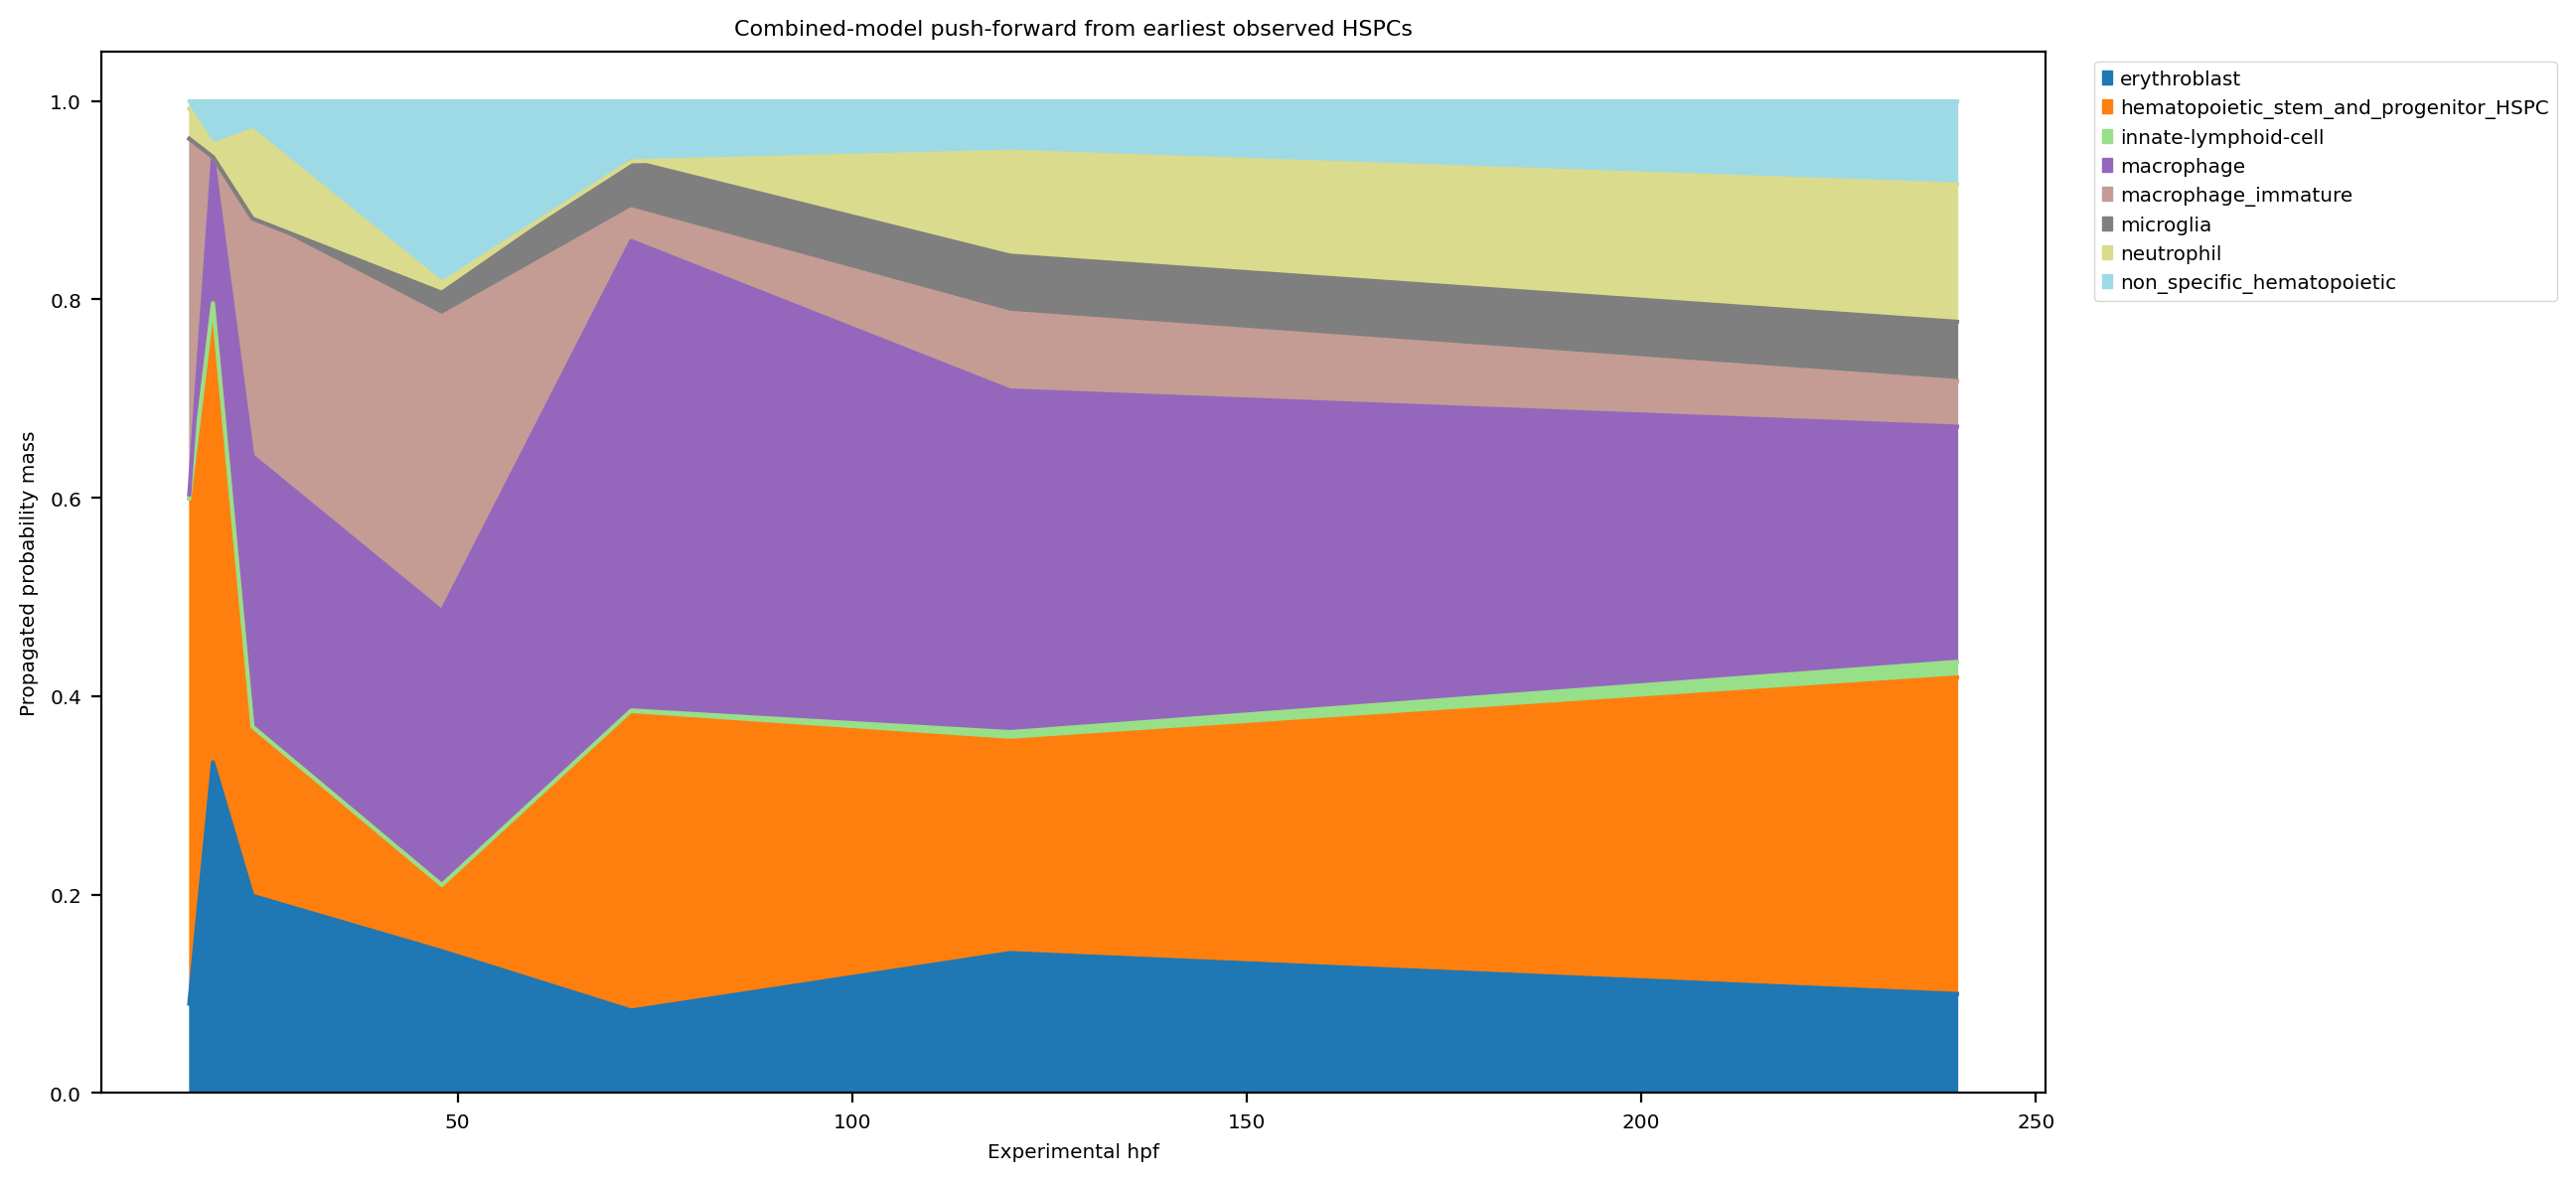

In [33]:
hspc_stages = [
    t for t in timepoints
    if np.any((hpf == t) & (cell_types == HSPC_LABEL))
]
assert hspc_stages, "No HSPC cells found at any modeled time point."
start_hpf = min(hspc_stages)

start_global = np.flatnonzero(hpf == start_hpf)
start_hspc_local = np.flatnonzero(cell_types[start_global] == HSPC_LABEL)

distribution = np.zeros(len(start_global), dtype=float)
distribution[start_hspc_local] = 1.0 / len(start_hspc_local)

fate_records = []
current_hpf = start_hpf

for t0, t1 in time_pairs:
    if t0 < start_hpf:
        continue
    if t0 != current_hpf:
        raise RuntimeError(f"Broken sequential chain at {current_hpf} -> {t0}")

    result = combined_pairs[(t0, t1)]
    assert len(distribution) == result["Q_combined"].shape[0]
    distribution = np.asarray(distribution @ result["Q_combined"]).ravel()
    distribution = distribution / distribution.sum()

    target_labels = cell_types[result["target_global"]]
    summary = (
        pd.DataFrame({"cell_type": target_labels, "mass": distribution})
        .groupby("cell_type", observed=True)["mass"]
        .sum()
        .reset_index()
    )
    summary["hpf"] = t1
    fate_records.append(summary)
    current_hpf = t1

hspc_pushforward = pd.concat(fate_records, ignore_index=True)
hspc_pushforward.to_csv(
    RESULTS_DIR / "hspc_combined_pushforward_fates.csv",
    index=False,
)
display(hspc_pushforward.sort_values(["hpf", "mass"], ascending=[True, False]))

fate_plot = hspc_pushforward.pivot_table(
    index="hpf",
    columns="cell_type",
    values="mass",
    fill_value=0.0,
    observed=True,
)
fate_plot.plot.area(figsize=(13, 6), colormap="tab20")
plt.ylabel("Propagated probability mass")
plt.xlabel("Experimental hpf")
plt.title("Combined-model push-forward from earliest observed HSPCs")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "hspc_combined_pushforward_fates.pdf")
plt.show()

## 23. Convert combined couplings into real-time PCA velocities

For a source cell at (t_0), the combined expected finite-difference velocity is

\[
V_i^{real}=\sum_j Q_{ij}\frac{X_j-X_i}{t_1-t_0}.
\]

Its units are **PCA units per hpf**. This is the quantity that the old ODE was
missing. It is defined only for cells that occur as a source in a solved time
pair; the final time point has no forward observation and remains `NaN`.

Long intervals such as 120→240 hpf are average rates across a large gap, not
instantaneous velocities. They must be interpreted separately.

,,count,mean,std,min,25%,50%,75%,max
source_hpf,target_hpf,,,,,,,,
12.0,14.0,19.0,20.069975,10.607130,12.409000,15.464780,16.603027,19.592651,55.398550
14.0,16.0,77.0,20.490206,6.072182,11.379033,15.725198,20.191644,24.379165,40.247847
16.0,19.0,186.0,17.292217,4.396994,8.787637,14.526894,16.556768,19.149149,35.885554
19.0,24.0,79.0,28.837569,11.516336,9.428302,24.236856,25.725394,31.432916,74.836954
24.0,48.0,1177.0,17.239234,7.580712,1.948213,15.863555,18.810080,21.643399,41.055090
48.0,72.0,466.0,14.784111,17.767374,2.276945,4.258167,7.463878,17.929201,118.418995
72.0,120.0,528.0,7.815975,7.487455,1.094804,2.500967,4.702810,9.451595,37.076532
120.0,240.0,1456.0,1.204772,0.815130,0.330051,0.739708,0.936784,1.367825,10.364891


Cells with combined real-time velocity: 3988 / 5426


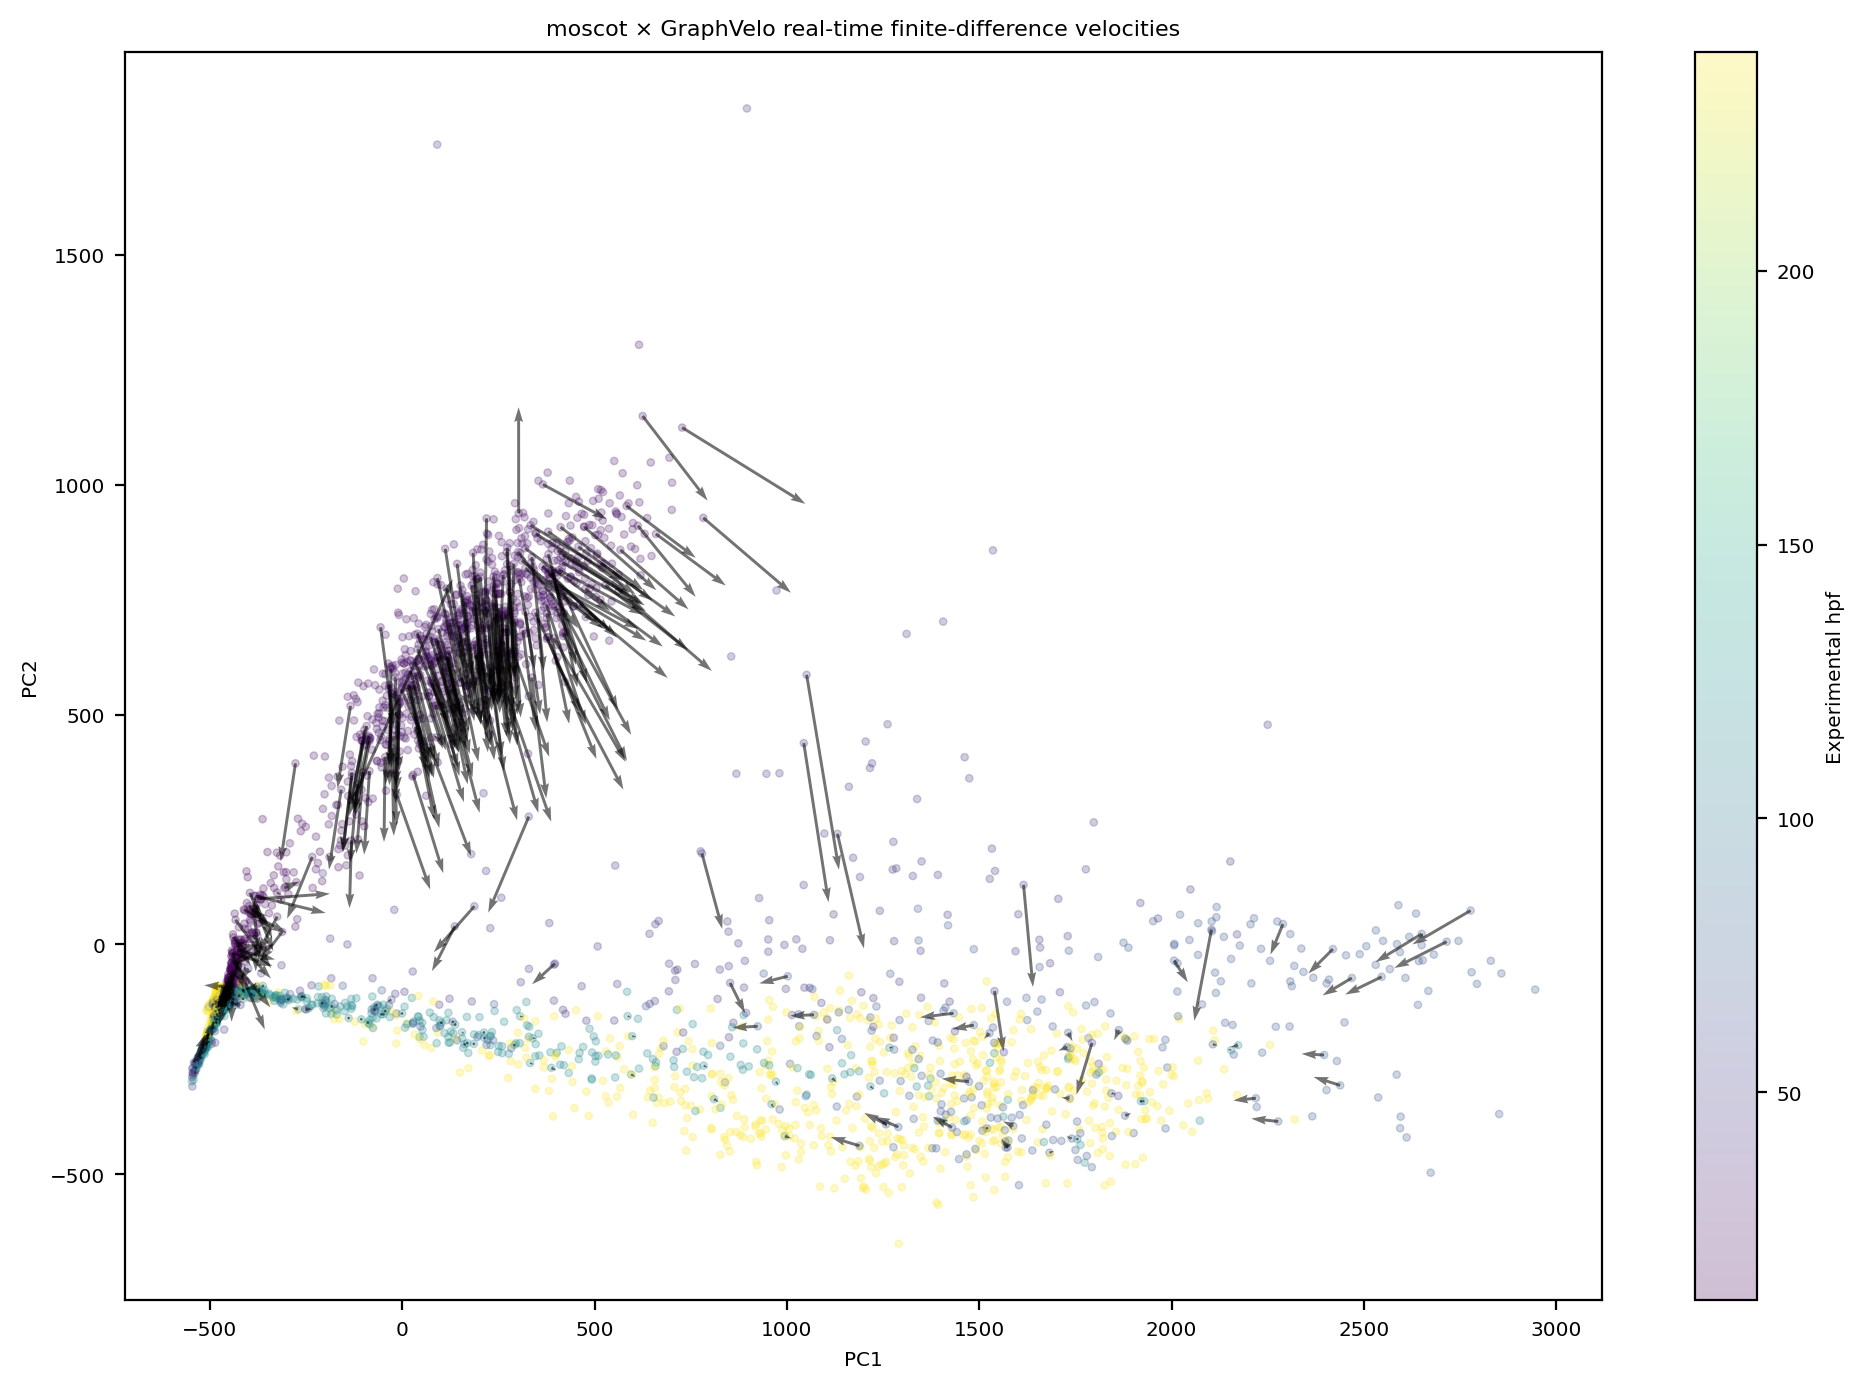

In [34]:
V_real = np.full_like(X_pca, np.nan, dtype=float)
real_velocity_records = []

for (t0, t1), result in combined_pairs.items():
    Q = result["Q_combined"].tocoo()
    source_global = result["source_global"]
    target_global = result["target_global"]

    src_global_edge = source_global[Q.row]
    tgt_global_edge = target_global[Q.col]
    edge_rate = (
        X_pca[tgt_global_edge] - X_pca[src_global_edge]
    ) / float(t1 - t0)

    local_velocity = np.zeros((len(source_global), X_pca.shape[1]), dtype=float)
    np.add.at(local_velocity, Q.row, Q.data[:, None] * edge_rate)
    V_real[source_global] = local_velocity

    norms = np.linalg.norm(local_velocity, axis=1)
    real_velocity_records.append(pd.DataFrame({
        "cell_id": adata.obs_names[source_global],
        "source_hpf": t0,
        "target_hpf": t1,
        "velocity_norm_pca_per_hpf": norms,
    }))

adata.obsm["moscot_graphvelo_real_time_pca"] = V_real
real_velocity_qc = pd.concat(real_velocity_records, ignore_index=True)
real_velocity_qc.to_csv(
    RESULTS_DIR / "moscot_graphvelo_real_time_velocity_qc.csv",
    index=False,
)
display(
    real_velocity_qc.groupby(["source_hpf", "target_hpf"])[
        "velocity_norm_pca_per_hpf"
    ].describe()
)

finite_velocity = np.isfinite(V_real).all(axis=1)
print("Cells with combined real-time velocity:", finite_velocity.sum(), "/", adata.n_obs)

# Visualization only: a reproducible subsample avoids an unreadable quiver plot.
plot_rng = np.random.default_rng(SEED)
eligible = np.flatnonzero(finite_velocity)
n_plot = min(700, len(eligible))
plot_idx = plot_rng.choice(eligible, size=n_plot, replace=False)

fig, ax = plt.subplots(figsize=(10, 7))
points = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], c=hpf, cmap="viridis",
    s=7, alpha=0.25, rasterized=True,
)
ax.quiver(
    X_pca[plot_idx, 0], X_pca[plot_idx, 1],
    V_real[plot_idx, 0], V_real[plot_idx, 1],
    color="black", alpha=0.55, angles="xy", scale_units="xy", scale=None,
    width=0.002,
)
fig.colorbar(points, ax=ax, label="Experimental hpf")
ax.set(
    title="moscot × GraphVelo real-time finite-difference velocities",
    xlabel="PC1", ylabel="PC2",
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "moscot_graphvelo_real_time_velocity_quiver.pdf")
plt.show()

## 24. Fish-level bootstrap with the fitted combined coupling

Cells from the same fish are not independent. This bootstrap resamples fish
within each source time point and re-aggregates the already-fitted combined
coupling. It estimates sampling uncertainty **conditional on the fitted
moscot/GraphVelo model**.

It does not include uncertainty from re-fitting moscot. A full model bootstrap
would resample fish, rebuild PCA/GraphVelo/moscot, and is substantially more
expensive. Report this distinction explicitly.

In [35]:
N_COMBINED_BOOT = 500
bootstrap_rng = np.random.default_rng(SEED)
bootstrap_rows = []

for (t0, t1), result in combined_pairs.items():
    Q = result["Q_combined"].tocsr()
    src_global = result["source_global"]
    tgt_global = result["target_global"]
    source_fish = fish_ids[src_global]
    unique_source_fish = np.unique(source_fish)
    target_labels = cell_types[tgt_global]

    for iteration in range(N_COMBINED_BOOT):
        sampled_fish = bootstrap_rng.choice(
            unique_source_fish,
            size=len(unique_source_fish),
            replace=True,
        )
        sampled_rows = np.concatenate([
            np.flatnonzero(source_fish == fish_id)
            for fish_id in sampled_fish
        ])

        # Duplicated row indices correctly represent a fish sampled repeatedly.
        sub = Q[sampled_rows, :].tocoo()
        sampled_global = src_global[sampled_rows]
        frame = pd.DataFrame({
            "source": cell_types[sampled_global[sub.row]],
            "target": target_labels[sub.col],
            "mass": sub.data,
        })
        grouped = (
            frame.groupby(["source", "target"], observed=True)["mass"]
            .sum()
            .reset_index()
        )
        totals = grouped.groupby("source", observed=True)["mass"].transform("sum")
        grouped["weight"] = grouped["mass"] / totals
        grouped["iteration"] = iteration
        grouped["source_hpf"] = t0
        grouped["target_hpf"] = t1
        bootstrap_rows.append(grouped)

combined_bootstrap = pd.concat(bootstrap_rows, ignore_index=True)
combined_ci = (
    combined_bootstrap.groupby(
        ["source_hpf", "target_hpf", "source", "target"],
        observed=True,
    )["weight"]
    .quantile([0.025, 0.5, 0.975])
    .unstack()
    .rename(columns={0.025: "ci_low", 0.5: "median", 0.975: "ci_high"})
    .reset_index()
)
combined_ci.to_csv(
    RESULTS_DIR / "moscot_graphvelo_fish_bootstrap_ci.csv",
    index=False,
)
display(
    combined_ci.loc[combined_ci["source"].eq(HSPC_LABEL)]
    .sort_values(["source_hpf", "median"], ascending=[True, False])
)

,source_hpf,target_hpf,source,target,ci_low,median,ci_high
27,14.0,16.0,hematopoietic_stem_and_progenitor_HSPC,hematopoietic_stem_and_progenitor_HSPC,5.092641e-01,0.509264,0.509264
29,14.0,16.0,hematopoietic_stem_and_progenitor_HSPC,macrophage_immature,3.583650e-01,0.358365,0.358365
26,14.0,16.0,hematopoietic_stem_and_progenitor_HSPC,erythroblast,9.015490e-02,0.090155,0.090155
30,14.0,16.0,hematopoietic_stem_and_progenitor_HSPC,neutrophil,3.045527e-02,0.030455,0.030455
31,14.0,16.0,hematopoietic_stem_and_progenitor_HSPC,non_specific_hematopoietic,7.724649e-03,0.007725,0.007725
28,14.0,16.0,hematopoietic_stem_and_progenitor_HSPC,macrophage,4.036081e-03,0.004036,0.004036
57,16.0,19.0,hematopoietic_stem_and_progenitor_HSPC,hematopoietic_stem_and_progenitor_HSPC,4.163181e-01,0.456034,0.482603
56,16.0,19.0,hematopoietic_stem_and_progenitor_HSPC,erythroblast,2.119600e-01,0.248537,0.278523
58,16.0,19.0,hematopoietic_stem_and_progenitor_HSPC,macrophage,1.253647e-01,0.195966,0.263678
61,16.0,19.0,hematopoietic_stem_and_progenitor_HSPC,non_specific_hematopoietic,2.056334e-02,0.071740,0.114937


## 25. Sensitivity to GraphVelo strength κ

The combined conclusion must not depend on a single arbitrary `GV_KAPPA`.
This section reweights the fixed moscot edges at κ = 0,1,2,5. κ=0 is the
moscot-only top-k baseline. Stable HSPC targets should remain visible across a
reasonable range.

This does not test `epsilon`, `tau`, PCA choice, geodesic cost, or `OT_TOPK`;
those require re-solving moscot and should be added to a full robustness run.

In [36]:
KAPPA_GRID = [0.0, 1.0, 2.0, 5.0]
sensitivity_records = []

for (t0, t1), result in combined_pairs.items():
    edges = result["edge_table"].copy()
    src_local = edges["source_local"].to_numpy(int)
    ot_mass = edges["ot_mass"].to_numpy(float)
    cosine = edges["gv_cosine"].to_numpy(float)

    for kappa in KAPPA_GRID:
        log_mass = OT_ALPHA * np.log(ot_mass + NUMERIC_EPS) + kappa * cosine
        row_max = np.full(len(result["source_global"]), -np.inf)
        np.maximum.at(row_max, src_local, log_mass)
        raw = np.exp(log_mass - row_max[src_local])
        row_sum = np.bincount(
            src_local, weights=raw, minlength=len(result["source_global"])
        )
        normalized = raw / row_sum[src_local]

        tmp = pd.DataFrame({
            "source": edges["source_type"].to_numpy(),
            "target": edges["target_type"].to_numpy(),
            "weight": normalized,
        })
        agg = (
            tmp.groupby(["source", "target"], observed=True)["weight"]
            .sum()
            .reset_index()
        )
        totals = agg.groupby("source", observed=True)["weight"].transform("sum")
        agg["weight"] = agg["weight"] / totals
        agg["kappa"] = kappa
        agg["source_hpf"] = t0
        agg["target_hpf"] = t1
        sensitivity_records.append(agg)

kappa_sensitivity = pd.concat(sensitivity_records, ignore_index=True)
kappa_sensitivity.to_csv(
    RESULTS_DIR / "moscot_graphvelo_kappa_sensitivity.csv",
    index=False,
)

hspc_kappa = kappa_sensitivity.loc[
    kappa_sensitivity["source"].eq(HSPC_LABEL)
]
display(
    hspc_kappa.sort_values(
        ["source_hpf", "kappa", "weight"],
        ascending=[True, True, False],
    )
)

,source,target,weight,kappa,source_hpf,target_hpf
87,hematopoietic_stem_and_progenitor_HSPC,hematopoietic_stem_and_progenitor_HSPC,0.510959,0.0,14.0,16.0
89,hematopoietic_stem_and_progenitor_HSPC,macrophage_immature,0.356766,0.0,14.0,16.0
86,hematopoietic_stem_and_progenitor_HSPC,erythroblast,0.077615,0.0,14.0,16.0
90,hematopoietic_stem_and_progenitor_HSPC,neutrophil,0.032143,0.0,14.0,16.0
91,hematopoietic_stem_and_progenitor_HSPC,non_specific_hematopoietic,0.018385,0.0,14.0,16.0
...,...,...,...,...,...,...
1267,hematopoietic_stem_and_progenitor_HSPC,macrophage,0.075030,5.0,120.0,240.0
1271,hematopoietic_stem_and_progenitor_HSPC,non_specific_hematopoietic,0.054841,5.0,120.0,240.0
1268,hematopoietic_stem_and_progenitor_HSPC,macrophage_immature,0.046691,5.0,120.0,240.0
1266,hematopoietic_stem_and_progenitor_HSPC,innate-lymphoid-cell,0.016021,5.0,120.0,240.0


## 26. Optional real-time ODE (disabled by default)

Unlike the removed ODE, this experimental model uses a velocity measured in
PCA units/hpf and includes hpf as an input to a non-autonomous vector field:

\[
\frac{dX}{dt_{hpf}}=F(X,t_{hpf}).
\]

It uses all modeled blood states rather than manually declaring branch label
lists. A nearest-neighbor support event stops an integration when it leaves the
observed state-time manifold.

Even after these improvements, this remains exploratory because:

1. velocities across large hpf gaps are interval averages;
2. KNN interpolation between discrete stages is not directly observed;
3. a 10-dimensional integral is displayed only in PC1/PC2;
4. numerical streamlines are not lineage-tracing evidence.

Run only after moscot convergence, pair diagnostics, κ sensitivity, and fish
bootstrap have been reviewed.

In [37]:
RUN_OPTIONAL_REAL_TIME_ODE = False

if RUN_OPTIONAL_REAL_TIME_ODE:
    from scipy.integrate import solve_ivp
    from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
    from sklearn.preprocessing import StandardScaler

    ODE_PCS = min(10, X_pca.shape[1])
    ODE_K = 30
    ODE_N_STARTS = 5

    train_mask = np.isfinite(V_real[:, :ODE_PCS]).all(axis=1)
    X_train = X_pca[train_mask, :ODE_PCS]
    t_train = hpf[train_mask]
    V_train = V_real[train_mask, :ODE_PCS]

    # Standardize state and time only for neighbor-distance calculations.
    features = np.column_stack([X_train, t_train])
    feature_scaler = StandardScaler().fit(features)
    features_scaled = feature_scaler.transform(features)

    field = KNeighborsRegressor(
        n_neighbors=min(ODE_K, len(features_scaled)),
        weights="distance",
        n_jobs=-1,
    ).fit(features_scaled, V_train)

    # Define observed support by the 99th percentile distance to the 10th
    # neighbor in joint state-time space.
    support_k = min(10, len(features_scaled))
    support_nn = NearestNeighbors(n_neighbors=support_k).fit(features_scaled)
    support_distances = support_nn.kneighbors(features_scaled)[0][:, -1]
    support_radius = np.quantile(support_distances, 0.99)

    def ode_rhs(t, x):
        query = feature_scaler.transform(
            np.concatenate([x, [t]]).reshape(1, -1)
        )
        return field.predict(query)[0]

    def support_event(t, x):
        query = feature_scaler.transform(
            np.concatenate([x, [t]]).reshape(1, -1)
        )
        nearest = support_nn.kneighbors(query, n_neighbors=1)[0][0, 0]
        return support_radius - nearest

    support_event.terminal = True
    support_event.direction = -1

    hspc_idx = np.flatnonzero(cell_types == HSPC_LABEL)
    earliest_hspc_hpf = hpf[hspc_idx].min()
    starts = hspc_idx[hpf[hspc_idx] == earliest_hspc_hpf]
    ode_rng = np.random.default_rng(SEED)
    if len(starts) > ODE_N_STARTS:
        starts = ode_rng.choice(starts, size=ODE_N_STARTS, replace=False)

    ode_solutions = []
    min_time_step = np.min(np.diff(timepoints))
    for cell_index in starts:
        solution = solve_ivp(
            fun=ode_rhs,
            t_span=(earliest_hspc_hpf, timepoints.max()),
            y0=X_pca[cell_index, :ODE_PCS],
            events=support_event,
            max_step=min_time_step / 4.0,
            rtol=1e-5,
            atol=1e-7,
        )
        assert solution.success, solution.message
        ode_solutions.append(solution)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.15, color="gray")
    for solution in ode_solutions:
        ax.plot(solution.y[0], solution.y[1], linewidth=2)
        ax.scatter(solution.y[0, 0], solution.y[1, 0], marker="*", s=100)
    ax.set(
        title="Exploratory real-time ODE from earliest observed HSPCs",
        xlabel="PC1", ylabel="PC2",
    )
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "optional_moscot_graphvelo_real_time_ode.pdf")
    plt.show()
else:
    print(
        "Optional ODE skipped. Review combined transitions and sensitivity "
        "diagnostics before setting RUN_OPTIONAL_REAL_TIME_ODE=True."
    )

Optional ODE skipped. Review combined transitions and sensitivity diagnostics before setting RUN_OPTIONAL_REAL_TIME_ODE=True.


## 17. Human ortholog handoff

Ortholog mapping should be performed with a versioned source such as ZFIN or

Ensembl BioMart. Zebrafish paralogs must not be converted by merely uppercasing
gene symbols. This notebook exports the branch-relevant zebrafish genes and a
template for a separately provenance-tracked mapping.

In [38]:
branch_gene_scores = pd.DataFrame(index=adata.var_names)
branch_gene_scores["velocity_qc_pass"] = adata.var["velocity_qc_pass"].astype(bool)
# branch_gene_scores["mean_abs_graphvelo_velocity"] = np.mean(np.abs(np.asarray(adata.layers["velocity_gv"])), axis=0)

# velocity_gv is sparse
V_gv = adata.layers["velocity_gv"]

if sp.issparse(V_gv):
    mean_abs_velocity = np.asarray(abs(V_gv).mean(axis=0)).ravel()
    # convert 2D into 1D
else:
    mean_abs_velocity = np.mean(np.abs(V_gv),axis=0)

branch_gene_scores[
    "mean_abs_graphvelo_velocity"
] = mean_abs_velocity


branch_gene_scores["expression_variance"] = np.var(
    adata.layers["M_s"].toarray()
    if sp.issparse(adata.layers["M_s"])
    else np.asarray(adata.layers["M_s"]),
    axis=0,
)
branch_gene_scores = branch_gene_scores.sort_values(
    ["velocity_qc_pass", "mean_abs_graphvelo_velocity"],
    ascending=False,
)
branch_gene_scores.to_csv(RESULTS_DIR / "zebrafish_dynamic_gene_candidates.csv")

ortholog_template = pd.DataFrame(columns=[
    "zebrafish_gene",
    "human_ortholog",
    "orthology_type",
    "source_database",
    "source_release",
    "retrieval_date",
])
ortholog_template.to_csv(RESULTS_DIR / "zebrafish_human_ortholog_template.csv", index=False)
display(branch_gene_scores.head(50))

,velocity_qc_pass,mean_abs_graphvelo_velocity,expression_variance
Gene,,,
hbbe1.3,True,12.988908,156655.103933
hbae3,True,9.851865,49862.458939
hbae1.3,True,8.081110,33702.189349
hbbe3,True,7.195968,99196.199036
hbae1.1,True,2.641981,3859.969624
hbae1.3-1,True,2.492957,10294.037302
hbbe2,True,2.029815,29217.607554
lyz,True,1.181838,40204.414393
tmsb4x,True,0.990906,7369.355040


## 27. Save the combined checkpoint and analysis manifest

The checkpoint contains the fitted GraphVelo results, moscot solutions stored
by the problem object where serializable, combined real-time velocities, and
auditable CSV outputs. Because backend solver objects may not serialize inside
AnnData, the essential derived matrices/results are stored explicitly rather
than relying on the Python `tp` object after the kernel exits.

In [39]:
# Store each local coupling with explicit source/target cell IDs. AnnData obsp
# cannot hold rectangular matrices between different time-point subsets.
adata.uns["moscot_graphvelo_couplings"] = {}
for (t0, t1), result in combined_pairs.items():
    key = f"{t0:g}_to_{t1:g}_hpf"
    adata.uns["moscot_graphvelo_couplings"][key] = {
        "source_cell_ids": adata.obs_names[result["source_global"]].to_numpy(),
        "target_cell_ids": adata.obs_names[result["target_global"]].to_numpy(),
        "moscot_topk_csr": result["P_ot"],
        "combined_csr": result["Q_combined"],
    }

adata.uns["moscot_graphvelo_manifest"] = {
    "time_key": "hpf",
    "state_space": "X_pca",
    "graphvelo_velocity": "gv_pca",
    "moscot_policy": "sequential",
    "moscot_cost": "sq_euclidean",
    "moscot_epsilon": MOSCOT_EPSILON,
    "moscot_tau_a": MOSCOT_TAU_A,
    "moscot_tau_b": MOSCOT_TAU_B,
    "ot_topk": OT_TOPK,
    "ot_alpha": OT_ALPHA,
    "graphvelo_kappa": GV_KAPPA,
    "combined_formula": "Q_ij proportional to P_ij^alpha * exp(kappa * cosine)",
    "real_time_velocity_units": "PCA units per hpf",
    "annotation_role": "aggregation_only_official_lineage_annotation",
    "uncertainty": "fish_bootstrap_conditional_on_fitted_coupling",
    "ode_default": False,
}

combined_checkpoint = RESULTS_DIR / "blood_graphvelo_moscot_combined.h5ad"
adata.write_h5ad(combined_checkpoint, compression="gzip")

print("Saved combined checkpoint:", combined_checkpoint)
print("Saved result tables:")
for result_file in sorted(RESULTS_DIR.glob("moscot_graphvelo*.csv")):
    print(" -", result_file)
print(" -", RESULTS_DIR / "hspc_combined_pushforward_fates.csv")

Saved combined checkpoint: /net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/blood_graphvelo_moscot_combined.h5ad
Saved result tables:
 - /net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/moscot_graphvelo_fish_bootstrap_ci.csv
 - /net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/moscot_graphvelo_kappa_sensitivity.csv
 - /net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/moscot_graphvelo_pair_diagnostics.csv
 - /net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/moscot_graphvelo_real_time_velocity_qc.csv
 - /net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/moscot_graphvelo_temporal_type_transitions.csv
 - /net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/hspc_combined_pushforward_fates.csv


## Interpretation checklist before reporting

1. Confirm every moscot pair converged.
2. Confirm top-k retains most transport mass; increase `OT_TOPK` if not.
3. Compare moscot-only, GraphVelo-only, and combined cell-type transitions.
4. Confirm GraphVelo weighting improves mean cosine without collapsing the
   coupling onto very few edges.
5. Inspect large-gap pairs (72→120 and 120→240 hpf) separately.
6. Confirm HSPC targets are stable across κ and, in a full run, across moscot
   `epsilon`, `tau`, top-k, PCA dimension, and cost choice.
7. Report fish-bootstrap intervals and state that they are conditional on the
   fitted coupling unless the entire model is re-fit per bootstrap.
8. Do not interpret transport mass as a measured clonal fraction.
9. Do not use thymocyte as a main conclusion because its cell count is very
   small.
10. Keep the optional ODE in backup until its manifold support, endpoints, and
    parameter sensitivity are validated.

Recommended conclusion language:

> moscot provides probabilistic couplings across observed experimental time
> points, and GraphVelo reweights those couplings using local transcriptional
> direction. The resulting transitions are model-supported developmental
> relationships among official cell types, not direct lineage-tracing proof.

,interval,ot_weighted_mean_cosine,combined_weighted_mean_cosine,cosine_improvement,ot_negative_cosine_mass,combined_negative_cosine_mass,negative_mass_reduction
0,12→14,0.681,0.713,0.031,0.000,0.000,0.000
1,14→16,0.153,0.235,0.082,0.400,0.312,0.088
2,16→19,0.100,0.216,0.116,0.448,0.352,0.096
3,19→24,0.197,0.307,0.110,0.302,0.225,0.077
4,24→48,0.011,0.081,0.070,0.497,0.421,0.077
5,48→72,0.268,0.359,0.092,0.261,0.163,0.097
6,72→120,-0.015,0.059,0.074,0.510,0.440,0.069
7,120→240,-0.082,0.068,0.150,0.580,0.433,0.147


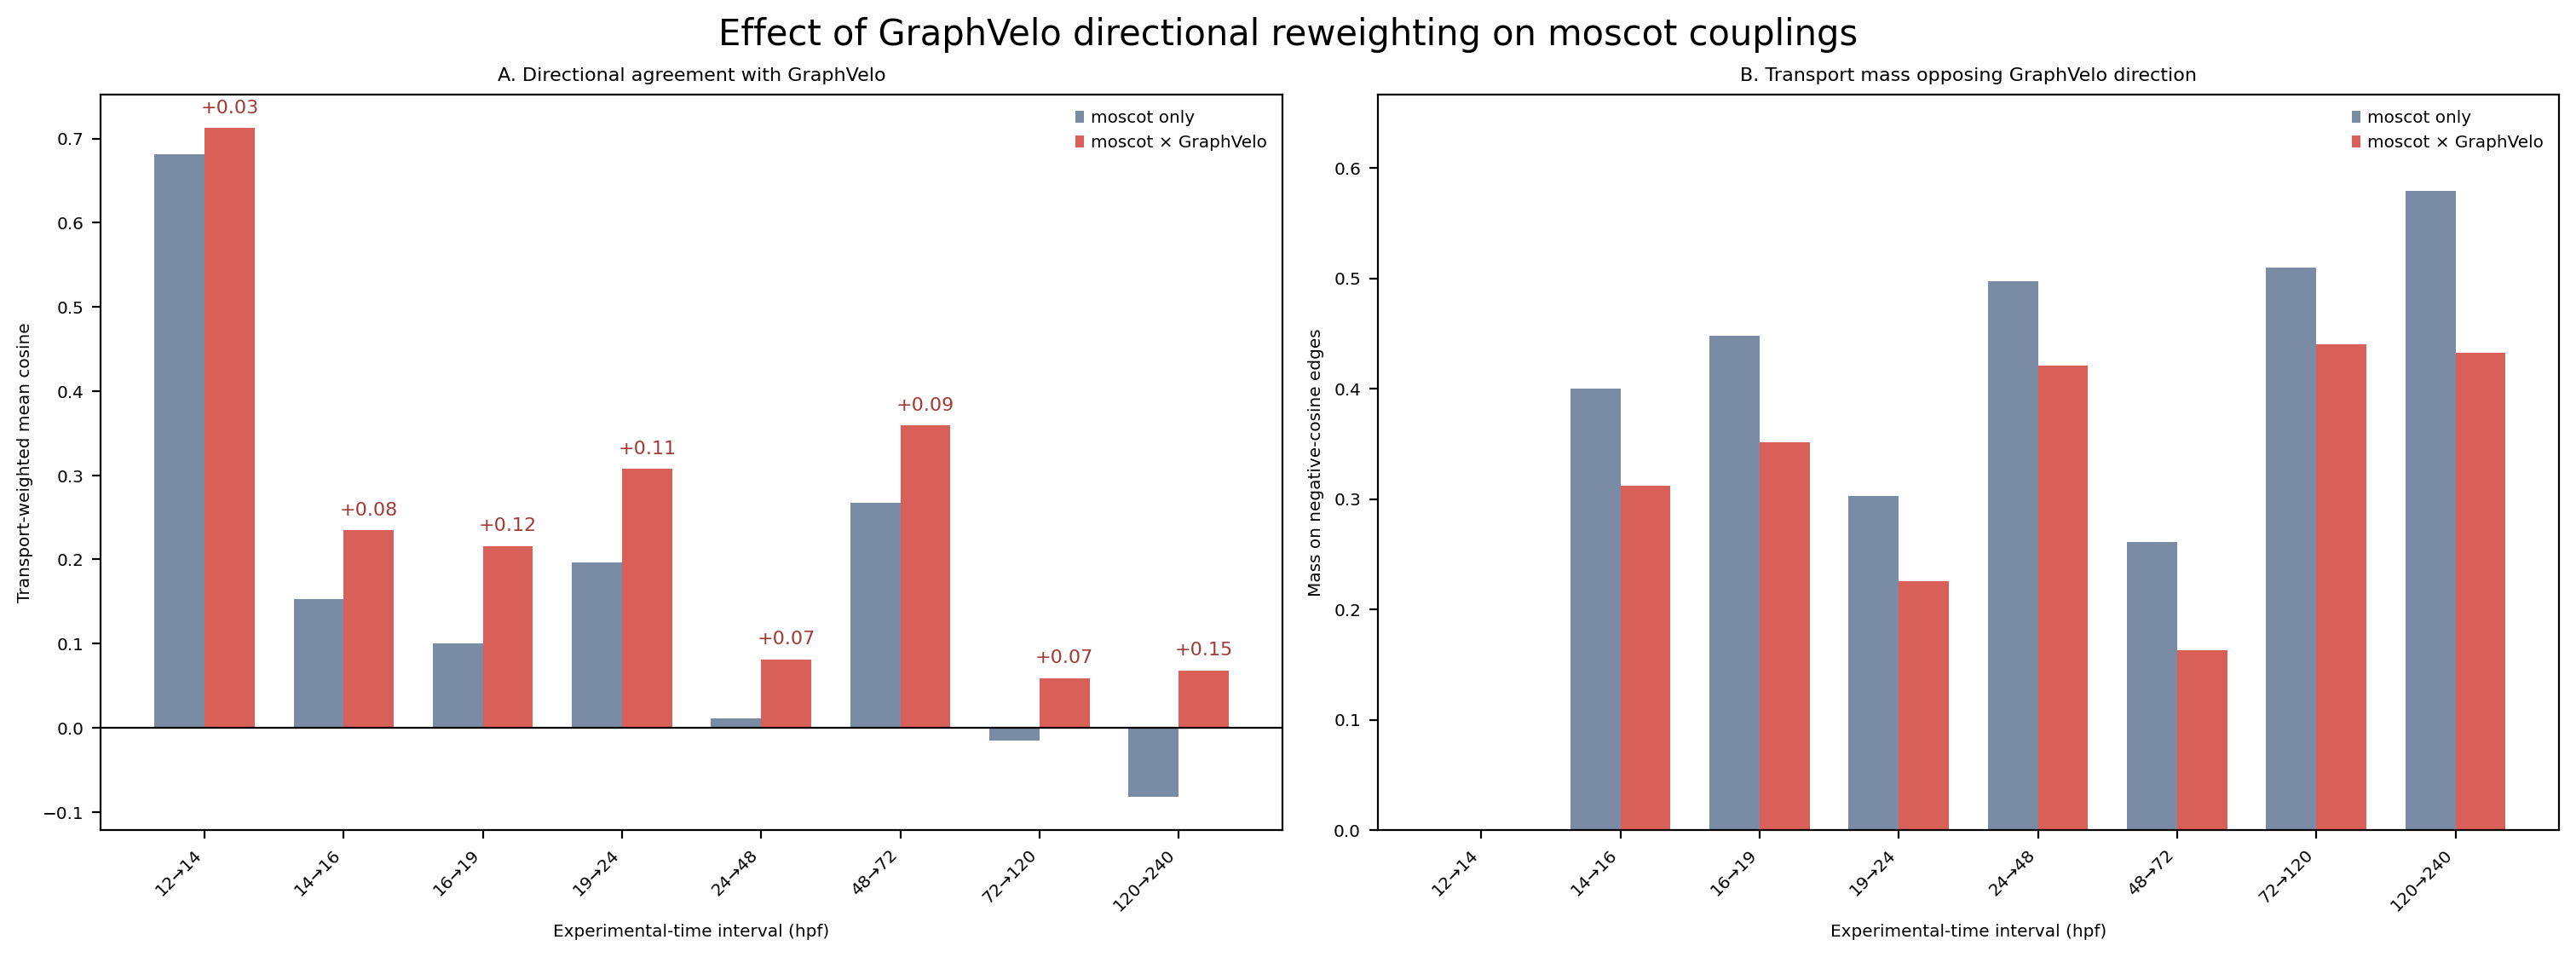

Saved:
 - /net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/figures/moscot_vs_combined_directional_diagnostics.pdf
 - /net/dali/home/mscbio/jis322/dynamo/blood_graphvelo_official/results/figures/moscot_vs_combined_directional_diagnostics.png


In [40]:
# ============================================================
# Direct comparison:
# moscot-only coupling vs. moscot × GraphVelo coupling
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# pair_diagnostics was generated when P_ot and Q_combined were constructed.
required_columns = {
    "source_hpf",
    "target_hpf",
    "ot_weighted_mean_cosine",
    "combined_weighted_mean_cosine",
    "ot_negative_cosine_mass",
    "combined_negative_cosine_mass",
}

missing_columns = required_columns - set(pair_diagnostics.columns)
assert not missing_columns, (
    f"pair_diagnostics is missing columns: {sorted(missing_columns)}"
)

comparison = (
    pair_diagnostics
    .sort_values(["source_hpf", "target_hpf"])
    .reset_index(drop=True)
    .copy()
)

comparison["interval"] = (
    comparison["source_hpf"].map(lambda x: f"{x:g}")
    + "→"
    + comparison["target_hpf"].map(lambda x: f"{x:g}")
)

# Improvement in directional alignment.
comparison["cosine_improvement"] = (
    comparison["combined_weighted_mean_cosine"]
    - comparison["ot_weighted_mean_cosine"]
)

# Reduction in probability mass assigned to directionally opposing edges.
comparison["negative_mass_reduction"] = (
    comparison["ot_negative_cosine_mass"]
    - comparison["combined_negative_cosine_mass"]
)

display(
    comparison[
        [
            "interval",
            "ot_weighted_mean_cosine",
            "combined_weighted_mean_cosine",
            "cosine_improvement",
            "ot_negative_cosine_mass",
            "combined_negative_cosine_mass",
            "negative_mass_reduction",
        ]
    ].round(3)
)

x = np.arange(len(comparison))
width = 0.36

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.5),
    constrained_layout=True,
)

# ------------------------------------------------------------
# Panel A: mean directional cosine
# Higher values indicate better agreement with GraphVelo.
# ------------------------------------------------------------
ax = axes[0]

bars_ot = ax.bar(
    x - width / 2,
    comparison["ot_weighted_mean_cosine"],
    width=width,
    color="#7A8CA5",
    label="moscot only",
)

bars_combined = ax.bar(
    x + width / 2,
    comparison["combined_weighted_mean_cosine"],
    width=width,
    color="#D95F59",
    label="moscot × GraphVelo",
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
)

ax.set_xticks(x)
ax.set_xticklabels(
    comparison["interval"],
    rotation=45,
    ha="right",
)

ax.set_xlabel("Experimental-time interval (hpf)")
ax.set_ylabel("Transport-weighted mean cosine")
ax.set_title(
    "A. Directional agreement with GraphVelo"
)
ax.legend(frameon=False)

# Show the amount of improvement above the combined bar.
for position, combined_value, improvement in zip(
    x,
    comparison["combined_weighted_mean_cosine"],
    comparison["cosine_improvement"],
):
    ax.annotate(
        f"+{improvement:.2f}",
        xy=(position + width / 2, combined_value),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#A33A35",
    )

# ------------------------------------------------------------
# Panel B: mass on edges opposing GraphVelo direction
# Lower values indicate better directional agreement.
# ------------------------------------------------------------
ax = axes[1]

ax.bar(
    x - width / 2,
    comparison["ot_negative_cosine_mass"],
    width=width,
    color="#7A8CA5",
    label="moscot only",
)

ax.bar(
    x + width / 2,
    comparison["combined_negative_cosine_mass"],
    width=width,
    color="#D95F59",
    label="moscot × GraphVelo",
)

ax.set_xticks(x)
ax.set_xticklabels(
    comparison["interval"],
    rotation=45,
    ha="right",
)

ax.set_xlabel("Experimental-time interval (hpf)")
ax.set_ylabel("Mass on negative-cosine edges")
ax.set_title(
    "B. Transport mass opposing GraphVelo direction"
)
ax.set_ylim(
    0,
    max(
        comparison["ot_negative_cosine_mass"].max(),
        comparison["combined_negative_cosine_mass"].max(),
    ) * 1.15,
)
ax.legend(frameon=False)

fig.suptitle(
    "Effect of GraphVelo directional reweighting on moscot couplings",
    fontsize=15,
)

# Save a vector PDF for the report and a high-resolution PNG for PowerPoint.
comparison_pdf = (
    FIGURE_DIR
    / "moscot_vs_combined_directional_diagnostics.pdf"
)
comparison_png = (
    FIGURE_DIR
    / "moscot_vs_combined_directional_diagnostics.png"
)

fig.savefig(
    comparison_pdf,
    bbox_inches="tight",
)

fig.savefig(
    comparison_png,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(" -", comparison_pdf)
print(" -", comparison_png)